<a href="https://colab.research.google.com/github/fouksiR/AGES-engage-/blob/main/Yousif_Clean_Pipeline_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparative Analysis of GnRH Agonist vs hCG Trigger on ART Outcomes in Warmed Oocyte Cycles

**Primary outcome:** Live birth rate  
**Secondary outcomes:** Oocyte maturation rate, fertilisation rate, embryo quality, clinical pregnancy rate  
**Statistical methods:** GEE (patient-level clustering) + propensity score matching  
**Thaw survival outcome:** Dropped due to data integrity issues (see §8)

## 1. Setup and Data Loading

All data are loaded once here. Every subsequent section references these objects.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Binomial
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import math
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ── Load raw sources ──
egg_freeze_path = "/content/drive/MyDrive/Yousif paper/Files directly from YA Key xslx/EggFreeze.csv"
egg_thaw_path   = "/content/drive/MyDrive/Yousif paper/Files directly from YA Key xslx/EggThaw.csv"
bio_items_path  = "/content/drive/MyDrive/Yousif paper/Files directly from YA Key xslx/BioItemsEggThaw.csv"

df_freeze_raw = pd.read_csv(egg_freeze_path, low_memory=False)
df_thaw_raw   = pd.read_csv(egg_thaw_path, low_memory=False)
df_bio_raw    = pd.read_csv(bio_items_path, low_memory=False)

print(f"Raw data loaded:")
print(f"  EggFreeze:        {len(df_freeze_raw):,} rows, {df_freeze_raw['TreatmentId'].nunique():,} unique cycles")
print(f"  EggThaw:          {len(df_thaw_raw):,} rows")
print(f"  BioItemsEggThaw:  {len(df_bio_raw):,} rows")

# ── Also load the pre-built clean dataset for analysis ──
df = pd.read_csv('/content/drive/MyDrive/Yousif paper/dataset1_bio_freeze.csv', low_memory=False)
print(f"\nClean dataset (dataset1_bio_freeze.csv):")
print(f"  Gametes:  {len(df):,}")
print(f"  Patients: {df['PatientID'].nunique():,}")
print(f"  Cycles:   {df['FreezeTreatmentId'].nunique():,}")

Mounted at /content/drive
Raw data loaded:
  EggFreeze:        5,783 rows, 5,470 unique cycles
  EggThaw:          820 rows
  BioItemsEggThaw:  7,687 rows

Clean dataset (dataset1_bio_freeze.csv):
  Gametes:  7,553
  Patients: 831
  Cycles:   1,086


## 2. Dataset Construction & Validation

### 2.1 Merge strategy

The analysis dataset links each gamete to its original freeze cycle:

```
BioItemsEggThaw.CreatedTreatmentId  →  EggFreeze.TreatmentId
```

This preserves all gametes that can be linked to a freeze cycle (98.3% capture rate). The EggThaw table is **not** used for the primary analysis — it is only relevant for thaw survival, which has been dropped (§8).

### 2.2 Trigger classification

| Drug name   | Trigger group  |
|-------------|----------------|
| Ovidrel     | hCG            |
| Pregnyl     | hCG            |
| Lucrin      | GnRH Agonist   |
| Decapeptyl  | GnRH Agonist   |

Two patients with missing trigger data were manually classified per clinical records (Patient 121091 → hCG; Patient 164682 → GnRH Agonist).

### 2.3 Outcome definitions

| Outcome | Definition | Level |
|---------|-----------|-------|
| Live birth | PregnancyStatusTypeName contains 'Deliver' | Cycle |
| Maturation | MaturityTypeName == 'MII' | Gamete |
| Fertilisation | FertCheckAmTypeName == '2PN' | Gamete |
| Embryo quality | GradeDay5 first character ≥ 3 (i.e., ≥3BB) | Gamete (MII subset) |
| Clinical pregnancy | ClinicalPregnancy == 1 | Cycle |

In [2]:
# ── Validation against Yousif's reference counts ──
print("VALIDATION AGAINST REFERENCE COUNTS")
print("="*60)

checks = {
    'Total gametes':  (len(df_bio_raw), 7687),
    'MI oocytes':     ((df_bio_raw['MaturityTypeName'] == 'MI').sum(), 23),
    'MI-MII oocytes': ((df_bio_raw['MaturityTypeName'] == 'MI-MII').sum(), 331),
    'MII oocytes':    ((df_bio_raw['MaturityTypeName'] == 'MII').sum(), 6883),
    'Deliveries':     (df_bio_raw['PregnancyStatusTypeName'].str.contains('Deliver', na=False, case=False).sum(), 358),
}

for label, (actual, expected) in checks.items():
    match = "✓" if abs(actual - expected) <= 5 else "✗"
    print(f"  {match} {label:20s}: {actual:,} (expected {expected:,})")

# Clean dataset checks
print(f"\nClean dataset (dataset1_bio_freeze.csv):")
print(f"  Gametes:    {len(df):,}")
print(f"  Delivered:  {df['is_delivered'].sum():,}")
print(f"  Capture:    {100 * df['is_delivered'].sum() / 358:.1f}% of reference deliveries")

VALIDATION AGAINST REFERENCE COUNTS
  ✓ Total gametes       : 7,687 (expected 7,687)
  ✓ MI oocytes          : 23 (expected 23)
  ✓ MI-MII oocytes      : 331 (expected 331)
  ✓ MII oocytes         : 6,883 (expected 6,883)
  ✓ Deliveries          : 358 (expected 358)

Clean dataset (dataset1_bio_freeze.csv):
  Gametes:    7,553
  Delivered:  329
  Capture:    91.9% of reference deliveries


## 3. Analysis Cohort Derivation

In [3]:
# ── Filter to analysis cohort ──
print("COHORT DERIVATION")
print("="*60)

n0 = len(df)
print(f"Step 0: All gametes in clean dataset: {n0:,}")

# Filter to hCG and GnRH Agonist
df_a = df[df['TriggerGroup'].isin(['hCG', 'GnRH_Agonist'])].copy()
n1 = len(df_a)
print(f"Step 1: hCG or GnRH Agonist only:    {n1:,} (excluded {n0 - n1:,} Other/Unknown)")

# Remove missing confounders
df_a = df_a.dropna(subset=['AgeAtFreeze', 'BMI']).copy()
n2 = len(df_a)
print(f"Step 2: Complete Age + BMI:           {n2:,} (excluded {n1 - n2:,} missing)")

print(f"\nFinal gamete-level cohort: {n2:,} gametes")
print(f"  Patients: {df_a['PatientID'].nunique():,}")
print(f"  Cycles:   {df_a['FreezeTreatmentId'].nunique():,}")
print(f"  hCG:      {(df_a['TriggerGroup']=='hCG').sum():,} gametes")
print(f"  GnRH:     {(df_a['TriggerGroup']=='GnRH_Agonist').sum():,} gametes")

# ── Create derived variables ──
df_a['TriggerGnRH'] = (df_a['TriggerGroup'] == 'GnRH_Agonist').astype(int)
df_a['LiveBirth']    = df_a['is_delivered'].astype(int)
df_a['IsMII']        = (df_a['MaturityTypeName'] == 'MII').astype(int)
df_a['Is2PN']        = df_a['is_2PN'].astype(int)
df_a['ClinPreg']     = df_a['is_clinical_pregnancy'].astype(int)

# Embryo quality (≥3BB) — only among gametes with a Day 5 grade
def is_high_quality(grade):
    if pd.isna(grade): return np.nan  # preserve missingness
    try:
        return 1 if int(str(grade).strip()[0]) >= 3 else 0
    except:
        return 0

df_a['HighQuality'] = df_a['GradeDay5'].apply(is_high_quality)

# Standardise confounders for modelling
df_a['Age_std'] = (df_a['AgeAtFreeze'] - df_a['AgeAtFreeze'].mean()) / df_a['AgeAtFreeze'].std()
df_a['BMI_std'] = (df_a['BMI'] - df_a['BMI'].mean()) / df_a['BMI'].std()

# ── Cycle-level aggregation (for live birth / clinical pregnancy) ──
df_cycle = df_a.groupby('FreezeTreatmentId').agg(
    PatientID       = ('PatientID', 'first'),
    TriggerGroup    = ('TriggerGroup', 'first'),
    TriggerGnRH     = ('TriggerGnRH', 'first'),
    LiveBirth       = ('LiveBirth', 'max'),
    ClinPreg        = ('ClinPreg', 'max'),
    AgeAtFreeze     = ('AgeAtFreeze', 'first'),
    BMI             = ('BMI', 'first'),
    nEggsFrozen     = ('nEggsFrozen', 'first'),
    nMII            = ('IsMII', 'sum'),
).reset_index()

df_cycle['Age_std']  = (df_cycle['AgeAtFreeze'] - df_cycle['AgeAtFreeze'].mean()) / df_cycle['AgeAtFreeze'].std()
df_cycle['BMI_std']  = (df_cycle['BMI'] - df_cycle['BMI'].mean()) / df_cycle['BMI'].std()
df_cycle['nMII_std'] = (df_cycle['nMII'] - df_cycle['nMII'].mean()) / df_cycle['nMII'].std()
df_cycle['Eggs_std'] = (df_cycle['nEggsFrozen'] - df_cycle['nEggsFrozen'].mean()) / df_cycle['nEggsFrozen'].std()

print(f"\nCycle-level dataset: {len(df_cycle):,} cycles")
print(f"  Live births: {df_cycle['LiveBirth'].sum():,} ({100*df_cycle['LiveBirth'].mean():.1f}%)")

COHORT DERIVATION
Step 0: All gametes in clean dataset: 7,553
Step 1: hCG or GnRH Agonist only:    7,542 (excluded 11 Other/Unknown)
Step 2: Complete Age + BMI:           7,439 (excluded 103 missing)

Final gamete-level cohort: 7,439 gametes
  Patients: 816
  Cycles:   1,068
  hCG:      4,521 gametes
  GnRH:     2,918 gametes

Cycle-level dataset: 1,068 cycles
  Live births: 268 (25.1%)


✓ Saved: FigureS1_CONSORT_Flowchart.png


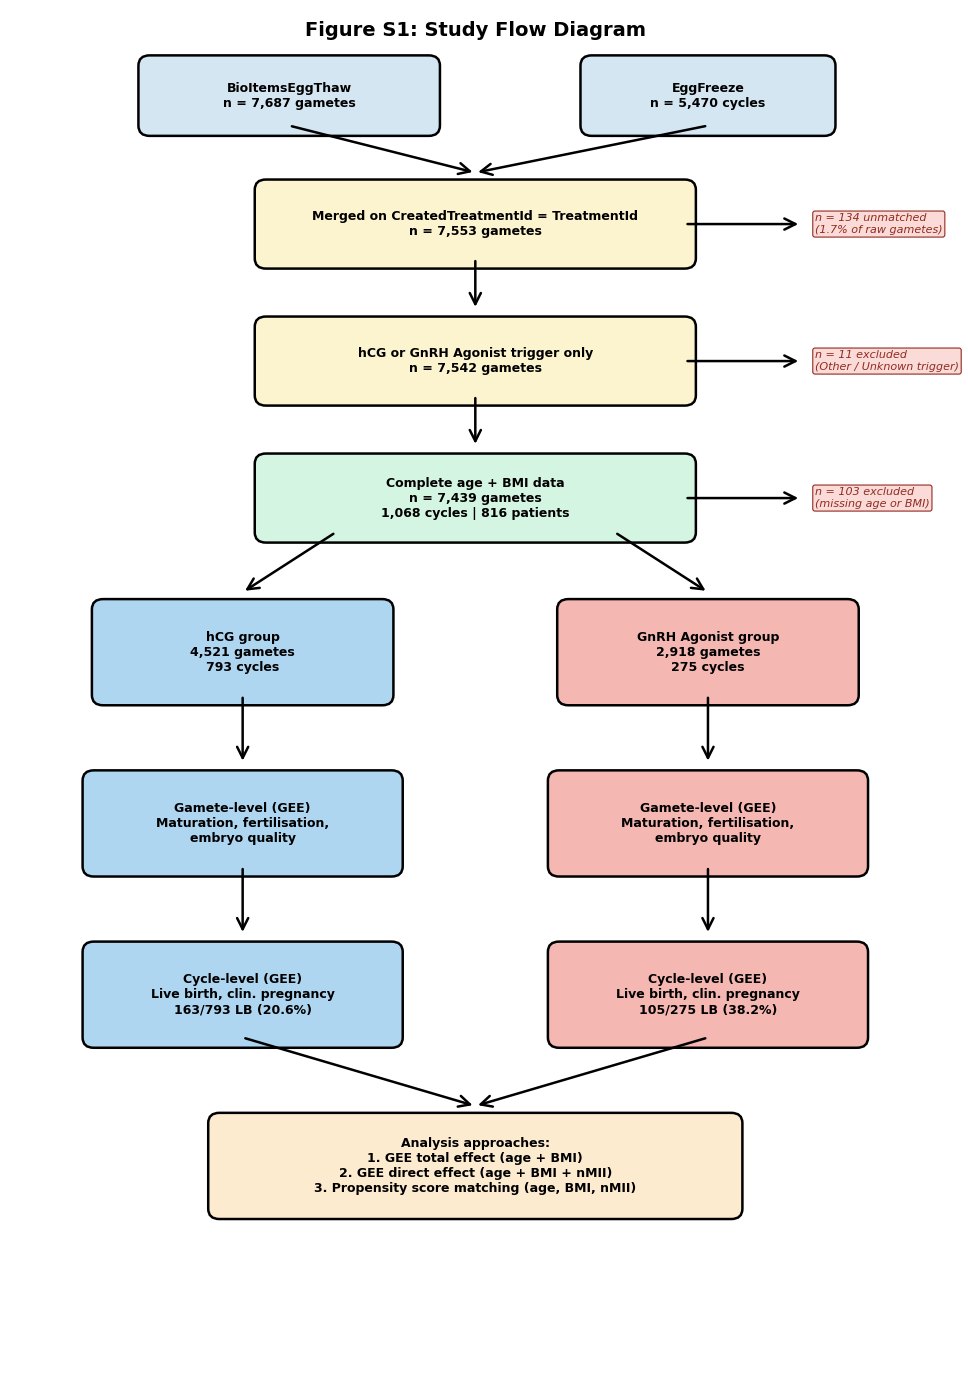

In [4]:
# ══════════════════════════════════════════════════════════════
# CONSORT-STYLE DATA DERIVATION FLOWCHART
# ══════════════════════════════════════════════════════════════
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_box(ax, x, y, w, h, text, color='#EBF5FB', fs=9):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.12",
                          ec='black', fc=color, lw=1.8)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, fontweight='bold')

def add_arrow(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->',
                                  mutation_scale=20, lw=1.8, color='black'))

def add_excl(ax, x_from, y_from, x_to, y_to, text):
    add_arrow(ax, x_from, y_from, x_to, y_to)
    ax.text(x_to + 0.15, y_to, text, ha='left', va='center', fontsize=8,
            fontstyle='italic', color='#922B21',
            bbox=dict(boxstyle='round,pad=0.2', fc='#FADBD8', ec='#922B21', lw=0.8))

# ── Calculate numbers ──
n_raw = 7687
n_merged = len(df)
n_merge_lost = n_raw - n_merged

n_trigger_filt = len(df[df['TriggerGroup'].isin(['hCG', 'GnRH_Agonist'])])
n_excl_trigger = n_merged - n_trigger_filt

df_tmp = df[df['TriggerGroup'].isin(['hCG', 'GnRH_Agonist'])].copy()
n_excl_bmi = df_tmp['BMI'].isna().sum() + df_tmp['AgeAtFreeze'].isna().sum()
# Use actual df_a from earlier
n_final_gametes = len(df_a)
n_final_patients = df_a['PatientID'].nunique()
n_final_cycles = df_a['FreezeTreatmentId'].nunique()
n_hcg_g = (df_a['TriggerGroup']=='hCG').sum()
n_gnrh_g = (df_a['TriggerGroup']=='GnRH_Agonist').sum()

hcg_c = len(df_cycle[df_cycle['TriggerGroup']=='hCG'])
gnrh_c = len(df_cycle[df_cycle['TriggerGroup']=='GnRH_Agonist'])
hcg_lb = df_cycle[df_cycle['TriggerGroup']=='hCG']['LiveBirth'].sum()
gnrh_lb = df_cycle[df_cycle['TriggerGroup']=='GnRH_Agonist']['LiveBirth'].sum()

# ── Draw ──
fig, ax = plt.subplots(figsize=(10, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 16)
ax.axis('off')

ax.text(5, 15.7, 'Figure S1: Study Flow Diagram', ha='center', fontsize=14, fontweight='bold')

# Row 1: Raw data
add_box(ax, 3, 15, 3, 0.7, f'BioItemsEggThaw\nn = {n_raw:,} gametes', '#D4E6F1')
add_box(ax, 7.5, 15, 2.5, 0.7, f'EggFreeze\nn = 5,470 cycles', '#D4E6F1')
add_arrow(ax, 3, 14.65, 5, 14.1)
add_arrow(ax, 7.5, 14.65, 5, 14.1)

# Row 2: Merge
add_box(ax, 5, 13.5, 4.5, 0.8, f'Merged on CreatedTreatmentId = TreatmentId\nn = {n_merged:,} gametes', '#FCF3CF')
add_excl(ax, 7.25, 13.5, 8.5, 13.5, f'n = {n_merge_lost:,} unmatched\n(1.7% of raw gametes)')
add_arrow(ax, 5, 13.1, 5, 12.5)

# Row 3: Trigger filter
add_box(ax, 5, 11.9, 4.5, 0.8, f'hCG or GnRH Agonist trigger only\nn = {n_trigger_filt:,} gametes', '#FCF3CF')
add_excl(ax, 7.25, 11.9, 8.5, 11.9, f'n = {n_excl_trigger:,} excluded\n(Other / Unknown trigger)')
add_arrow(ax, 5, 11.5, 5, 10.9)

# Row 4: Complete data
add_box(ax, 5, 10.3, 4.5, 0.8, f'Complete age + BMI data\nn = {n_final_gametes:,} gametes\n{n_final_cycles:,} cycles | {n_final_patients:,} patients', '#D5F5E3')
add_excl(ax, 7.25, 10.3, 8.5, 10.3, f'n = {n_trigger_filt - n_final_gametes:,} excluded\n(missing age or BMI)')
add_arrow(ax, 3.5, 9.9, 2.5, 9.2)
add_arrow(ax, 6.5, 9.9, 7.5, 9.2)

# Row 5: Split
add_box(ax, 2.5, 8.5, 3, 1, f'hCG group\n{n_hcg_g:,} gametes\n{hcg_c:,} cycles', '#AED6F1')
add_box(ax, 7.5, 8.5, 3, 1, f'GnRH Agonist group\n{n_gnrh_g:,} gametes\n{gnrh_c:,} cycles', '#F5B7B1')
add_arrow(ax, 2.5, 8.0, 2.5, 7.2)
add_arrow(ax, 7.5, 8.0, 7.5, 7.2)

# Row 6: Analysis levels
add_box(ax, 2.5, 6.5, 3.2, 1, f'Gamete-level (GEE)\nMaturation, fertilisation,\nembryo quality', '#AED6F1')
add_box(ax, 7.5, 6.5, 3.2, 1, f'Gamete-level (GEE)\nMaturation, fertilisation,\nembryo quality', '#F5B7B1')
add_arrow(ax, 2.5, 6.0, 2.5, 5.2)
add_arrow(ax, 7.5, 6.0, 7.5, 5.2)

add_box(ax, 2.5, 4.5, 3.2, 1, f'Cycle-level (GEE)\nLive birth, clin. pregnancy\n{hcg_lb}/{hcg_c} LB ({100*hcg_lb/hcg_c:.1f}%)', '#AED6F1')
add_box(ax, 7.5, 4.5, 3.2, 1, f'Cycle-level (GEE)\nLive birth, clin. pregnancy\n{gnrh_lb}/{gnrh_c} LB ({100*gnrh_lb/gnrh_c:.1f}%)', '#F5B7B1')

# Bottom: analysis approaches
add_arrow(ax, 2.5, 4.0, 5, 3.2)
add_arrow(ax, 7.5, 4.0, 5, 3.2)
add_box(ax, 5, 2.5, 5.5, 1.0,
        f'Analysis approaches:\n'
        f'1. GEE total effect (age + BMI)\n'
        f'2. GEE direct effect (age + BMI + nMII)\n'
        f'3. Propensity score matching (age, BMI, nMII)',
        '#FDEBD0', fs=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Yousif paper/FigureS1_CONSORT_Flowchart.png',
            dpi=300, bbox_inches='tight')
print("✓ Saved: FigureS1_CONSORT_Flowchart.png")
plt.show()

## 4. Table 1 — Baseline Characteristics by Trigger Group

Publication-ready demographics table with p-values for between-group comparisons.

In [5]:
# ── Table 1: Baseline Characteristics ──
def table1_row_continuous(data, col, label, by='TriggerGroup'):
    groups = data.groupby(by)[col]
    hcg = groups.get_group('hCG').dropna()
    gnrh = groups.get_group('GnRH_Agonist').dropna()
    _, p = stats.ttest_ind(hcg, gnrh)
    return {
        'Variable': label,
        'hCG (n={})'.format(len(data[data[by]=='hCG'])): f"{hcg.mean():.1f} ± {hcg.std():.1f}",
        'GnRH Agonist (n={})'.format(len(data[data[by]=='GnRH_Agonist'])): f"{gnrh.mean():.1f} ± {gnrh.std():.1f}",
        'p-value': f"{p:.3f}" if p >= 0.001 else "<0.001",
    }

def table1_row_categorical(data, col, label, by='TriggerGroup'):
    ct = pd.crosstab(data[by], data[col])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    hcg_n = data[data[by]=='hCG'][col].sum()
    hcg_pct = 100 * data[data[by]=='hCG'][col].mean()
    gnrh_n = data[data[by]=='GnRH_Agonist'][col].sum()
    gnrh_pct = 100 * data[data[by]=='GnRH_Agonist'][col].mean()
    n_hcg = len(data[data[by]=='hCG'])
    n_gnrh = len(data[data[by]=='GnRH_Agonist'])
    return {
        'Variable': label,
        f'hCG (n={n_hcg})': f"{hcg_n} ({hcg_pct:.1f}%)",
        f'GnRH Agonist (n={n_gnrh})': f"{gnrh_n} ({gnrh_pct:.1f}%)",
        'p-value': f"{p:.3f}" if p >= 0.001 else "<0.001",
    }

rows = [
    table1_row_continuous(df_cycle, 'AgeAtFreeze', 'Age at freeze, years'),
    table1_row_continuous(df_cycle, 'BMI', 'BMI, kg/m²'),
    table1_row_continuous(df_cycle, 'nEggsFrozen', 'Eggs frozen, n'),
    table1_row_continuous(df_cycle, 'nMII', 'MII oocytes, n'),
]

table1 = pd.DataFrame(rows)
print("TABLE 1: Baseline Characteristics by Trigger Group (Cycle Level)")
print("="*80)
print(table1.to_string(index=False))
print("\nValues are mean ± SD. P-values from independent t-test.")

TABLE 1: Baseline Characteristics by Trigger Group (Cycle Level)
            Variable hCG (n=793) GnRH Agonist (n=275) p-value
Age at freeze, years  36.9 ± 4.1           34.9 ± 4.1  <0.001
          BMI, kg/m²  24.8 ± 5.7           26.0 ± 5.8   0.002
      Eggs frozen, n   7.9 ± 5.2           15.0 ± 8.6  <0.001
      MII oocytes, n   5.1 ± 3.8            9.7 ± 6.3  <0.001

Values are mean ± SD. P-values from independent t-test.


## 5. Assessment of Data Clustering

The data are hierarchical: multiple oocytes per freeze cycle, potentially multiple cycles per patient. We assess both levels.

In [6]:
# ── Clustering assessment ──
print("CLUSTERING ASSESSMENT")
print("="*60)

# Level 1: Gametes within cycles
cycle_sizes = df_a.groupby('FreezeTreatmentId').size()
print(f"Level 1: Gametes within freeze cycles")
print(f"  Clusters (cycles): {len(cycle_sizes):,}")
print(f"  Gametes per cycle: mean={cycle_sizes.mean():.1f}, median={cycle_sizes.median():.0f}, "
      f"range={cycle_sizes.min()}-{cycle_sizes.max()}")

# Level 2: Cycles within patients
patient_cycles = df_cycle.groupby('PatientID').size()
print(f"\nLevel 2: Cycles within patients")
print(f"  Patients: {len(patient_cycles):,}")
print(f"  Cycles per patient: mean={patient_cycles.mean():.2f}, median={patient_cycles.median():.0f}, "
      f"range={patient_cycles.min()}-{patient_cycles.max()}")
multi_cycle = (patient_cycles > 1).sum()
print(f"  Patients with >1 cycle: {multi_cycle} ({100*multi_cycle/len(patient_cycles):.1f}%)")

# ICC for LiveBirth at cycle level (gametes within cycles)
cluster_means = df_a.groupby('FreezeTreatmentId')['LiveBirth'].mean()
overall_mean  = df_a['LiveBirth'].mean()
cluster_n     = df_a.groupby('FreezeTreatmentId')['LiveBirth'].count()
var_between   = ((cluster_means - overall_mean)**2 * cluster_n).sum() / (len(cluster_means) - 1)
var_within    = overall_mean * (1 - overall_mean)
icc = var_between / (var_between + var_within) if (var_between + var_within) > 0 else 0
deff = 1 + (cycle_sizes.mean() - 1) * icc

print(f"\nIntra-cluster correlation (ICC) for live birth: {icc:.4f}")
print(f"Design effect: {deff:.3f}")

# Decision
print(f"\nCLUSTERING DECISION:")
if multi_cycle / len(patient_cycles) < 0.10:
    print(f"  Only {100*multi_cycle/len(patient_cycles):.1f}% of patients have multiple cycles.")
    print(f"  → Cluster at CYCLE level (FreezeTreatmentId) for GEE.")
    print(f"  → Patient-level clustering negligible; no nested model needed.")
else:
    print(f"  {100*multi_cycle/len(patient_cycles):.1f}% of patients have multiple cycles.")
    print(f"  → Consider clustering at PATIENT level for robustness.")

CLUSTERING ASSESSMENT
Level 1: Gametes within freeze cycles
  Clusters (cycles): 1,068
  Gametes per cycle: mean=7.0, median=6, range=1-37

Level 2: Cycles within patients
  Patients: 816
  Cycles per patient: mean=1.31, median=1, range=1-9
  Patients with >1 cycle: 168 (20.6%)

Intra-cluster correlation (ICC) for live birth: 0.5106
Design effect: 4.046

CLUSTERING DECISION:
  20.6% of patients have multiple cycles.
  → Consider clustering at PATIENT level for robustness.


## 6. Primary Outcome: Live Birth Rate

### Causal model and adjustment strategy

The trigger is administered before egg retrieval. Two valid clinical questions arise:

| Question | Adjustment set | Interpretation |
|----------|---------------|----------------|
| **Total effect:** Does trigger choice matter for live birth overall? | Age + BMI (pre-treatment confounders) | Captures all pathways including better egg yield |
| **Direct effect:** Holding oocyte yield constant, does trigger affect per-oocyte quality? | Age + BMI + nMII | Isolates the quality pathway, equalises quantity |

Both are reported below. Additionally, **propensity score matching** on age, BMI, and nMII provides a non-parametric check that forces actual covariate overlap between groups.

Because 20.6% of patients contribute multiple freeze cycles (§5), all models use **GEE clustered at patient level**.

### 6.1 Progressive model table

In [7]:
# ── Primary outcome: Live birth rate ──
print("PRIMARY OUTCOME: LIVE BIRTH RATE")
print("="*70)

# Descriptive
for trigger in ['hCG', 'GnRH_Agonist']:
    sub = df_cycle[df_cycle['TriggerGroup'] == trigger]
    lb = sub['LiveBirth'].sum()
    n = len(sub)
    print(f"  {trigger:15s}: {lb:3d}/{n:3d} = {100*lb/n:.1f}%")

# ── Progressive models (cycle-level logistic, for transparency) ──
results_primary = []

formulas = {
    'Model 1 (Crude)':                'LiveBirth ~ TriggerGnRH',
    'Model 2 (Age + BMI)':            'LiveBirth ~ TriggerGnRH + Age_std + BMI_std',
    'Model 3 (Age + BMI + nMII)':     'LiveBirth ~ TriggerGnRH + Age_std + BMI_std + nMII_std',
    'Model 4 (+ Eggs frozen)':        'LiveBirth ~ TriggerGnRH + Age_std + BMI_std + nMII_std + Eggs_std',
}

print(f"\nProgressive model building (cycle-level logistic regression):")
print("-"*85)
print(f"{'Model':<35s} {'OR':>6s} {'95% CI':>18s} {'p':>8s}  {'Interpretation'}")
print("-"*85)

interp = {
    'Model 1 (Crude)':            'Unadjusted',
    'Model 2 (Age + BMI)':        '← Total effect (confounders only)',
    'Model 3 (Age + BMI + nMII)': '← Direct effect (equalises quantity)',
    'Model 4 (+ Eggs frozen)':    'Over-adjusted (collinear with nMII)',
}

for name, formula in formulas.items():
    model = sm.GLM.from_formula(formula, data=df_cycle, family=sm.families.Binomial()).fit(disp=0)
    or_val = np.exp(model.params['TriggerGnRH'])
    ci = np.exp(model.conf_int().loc['TriggerGnRH'])
    p = model.pvalues['TriggerGnRH']
    results_primary.append({'Model': name, 'OR': or_val, 'CI_lo': ci[0], 'CI_hi': ci[1], 'p': p})
    p_str = f"{p:.4f}" if p >= 0.001 else "<0.001"
    print(f"  {name:<33s} {or_val:6.3f} ({ci[0]:.3f} – {ci[1]:.3f}) {p_str:>8s}  {interp.get(name, '')}")

print("-"*85)
print("Note: Model 4 adds eggs frozen which is collinear with nMII — shown for")
print("      completeness but not recommended. Models 2 and 3 are the key results.")

# ══════════════════════════════════════════════════════════════
# GEE MODELS (patient-level clustering)
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("GEE MODELS (Patient-Level Clustering)")
print("="*70)

df_gee_primary = df_cycle.sort_values('PatientID').copy()
df_gee_primary['Patient_cluster'] = pd.factorize(df_gee_primary['PatientID'])[0]

gee_models = {
    'GEE Crude':                      'LiveBirth ~ TriggerGnRH',
    'GEE Total effect (Age+BMI)':     'LiveBirth ~ TriggerGnRH + Age_std + BMI_std',
    'GEE Direct effect (Age+BMI+nMII)': 'LiveBirth ~ TriggerGnRH + Age_std + BMI_std + nMII_std',
}

gee_results = {}
print(f"\n{'Model':<42s} {'OR':>6s} {'95% CI':>18s} {'p':>8s}")
print("-"*80)

for name, formula in gee_models.items():
    gee_fit = GEE.from_formula(
        formula, groups='Patient_cluster', data=df_gee_primary,
        family=Binomial(), cov_struct=Exchangeable()
    ).fit()
    or_val = np.exp(gee_fit.params['TriggerGnRH'])
    ci = np.exp(gee_fit.conf_int().loc['TriggerGnRH'])
    p = gee_fit.pvalues['TriggerGnRH']
    gee_results[name] = {'OR': or_val, 'CI_lo': ci[0], 'CI_hi': ci[1], 'p': p}
    p_str = f"{p:.4f}" if p >= 0.001 else "<0.001"
    print(f"  {name:<40s} {or_val:6.3f} ({ci[0]:.3f} – {ci[1]:.3f}) {p_str:>8s}")

print("-"*80)

# Store for Table 2 / Forest plot
primary_crude  = gee_results['GEE Crude']
primary_total  = gee_results['GEE Total effect (Age+BMI)']
primary_direct = gee_results['GEE Direct effect (Age+BMI+nMII)']

# ══════════════════════════════════════════════════════════════
# PROPENSITY SCORE MATCHING
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PROPENSITY SCORE MATCHING")
print("="*70)
print("Matching on: Age, BMI, nMII (nearest-neighbour, caliper=0.2 SD)")

# Fit propensity model
match_vars = ['AgeAtFreeze', 'BMI', 'nMII']
df_psm = df_cycle.dropna(subset=match_vars).copy()

X = df_psm[match_vars].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y = df_psm['TriggerGnRH'].values

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X_scaled, y)
df_psm['propensity'] = ps_model.predict_proba(X_scaled)[:, 1]

# Nearest-neighbour matching (1:1, without replacement)
treated = df_psm[df_psm['TriggerGnRH'] == 1].copy()
control = df_psm[df_psm['TriggerGnRH'] == 0].copy()

caliper = 0.2 * df_psm['propensity'].std()
matched_pairs = []

control_available = control.index.tolist()

for idx, row in treated.iterrows():
    if not control_available:
        break
    ctrl_subset = control.loc[control_available]
    distances = abs(ctrl_subset['propensity'] - row['propensity'])
    nearest_idx = distances.idxmin()
    nearest_dist = distances[nearest_idx]
    if nearest_dist <= caliper:
        matched_pairs.append((idx, nearest_idx))
        control_available.remove(nearest_idx)

print(f"\nMatching results:")
print(f"  Treated (GnRH): {len(treated):,}")
print(f"  Control (hCG):  {len(control):,}")
print(f"  Matched pairs:  {len(matched_pairs):,}")
print(f"  Caliper: {caliper:.4f}")
print(f"  Unmatched GnRH: {len(treated) - len(matched_pairs):,}")

# Build matched dataset
treated_idx = [p[0] for p in matched_pairs]
control_idx = [p[1] for p in matched_pairs]
df_matched = pd.concat([df_psm.loc[treated_idx], df_psm.loc[control_idx]])

# Covariate balance check
print(f"\nCovariate balance (matched sample):")
print(f"  {'Variable':<20s} {'hCG':>10s} {'GnRH':>10s} {'SMD':>8s}")
print(f"  {'-'*50}")
for var in match_vars:
    m_hcg = df_matched[df_matched['TriggerGnRH']==0][var].mean()
    m_gnrh = df_matched[df_matched['TriggerGnRH']==1][var].mean()
    s_pooled = np.sqrt((df_matched[df_matched['TriggerGnRH']==0][var].std()**2 +
                         df_matched[df_matched['TriggerGnRH']==1][var].std()**2) / 2)
    smd = abs(m_gnrh - m_hcg) / s_pooled if s_pooled > 0 else 0
    balance = "✓" if smd < 0.1 else "⚠" if smd < 0.2 else "✗"
    print(f"  {var:<20s} {m_hcg:>10.1f} {m_gnrh:>10.1f} {smd:>7.3f} {balance}")

# Outcome in matched sample
lb_hcg_m = df_matched[df_matched['TriggerGnRH']==0]['LiveBirth']
lb_gnrh_m = df_matched[df_matched['TriggerGnRH']==1]['LiveBirth']

hcg_rate_m = 100 * lb_hcg_m.mean()
gnrh_rate_m = 100 * lb_gnrh_m.mean()

# McNemar-style paired comparison (or simple proportions for 1:1 matching)
contingency_m = np.array([
    [lb_gnrh_m.sum(), len(lb_gnrh_m) - lb_gnrh_m.sum()],
    [lb_hcg_m.sum(), len(lb_hcg_m) - lb_hcg_m.sum()]
])
chi2_m, p_psm = stats.chi2_contingency(contingency_m)[:2]

# OR from matched sample
a = lb_gnrh_m.sum()
b = len(lb_gnrh_m) - a
c = lb_hcg_m.sum()
d = len(lb_hcg_m) - c
or_psm = (a * d) / (b * c) if (b * c) > 0 else np.nan

# CI for OR (Woolf method)
se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d) if min(a,b,c,d) > 0 else np.nan
ci_lo_psm = np.exp(np.log(or_psm) - 1.96 * se_log_or) if not np.isnan(se_log_or) else np.nan
ci_hi_psm = np.exp(np.log(or_psm) + 1.96 * se_log_or) if not np.isnan(se_log_or) else np.nan

print(f"\nLive birth rate (matched sample, n={len(matched_pairs)} pairs):")
print(f"  hCG:  {lb_hcg_m.sum()}/{len(lb_hcg_m)} = {hcg_rate_m:.1f}%")
print(f"  GnRH: {lb_gnrh_m.sum()}/{len(lb_gnrh_m)} = {gnrh_rate_m:.1f}%")
p_str = f"{p_psm:.4f}" if p_psm >= 0.001 else "<0.001"
print(f"  OR: {or_psm:.3f} (95% CI: {ci_lo_psm:.3f}–{ci_hi_psm:.3f}), p={p_str}")

psm_result = {'OR': or_psm, 'CI_lo': ci_lo_psm, 'CI_hi': ci_hi_psm, 'p': p_psm,
              'n_pairs': len(matched_pairs)}

# ══════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("SUMMARY: PRIMARY OUTCOME — THREE APPROACHES AGREE")
print("="*70)
print(f"\n{'Approach':<45s} {'OR':>6s} {'95% CI':>18s} {'p':>8s}")
print("-"*80)
for label, r in [
    ('GEE Total effect (Age+BMI)', primary_total),
    ('GEE Direct effect (Age+BMI+nMII)', primary_direct),
    (f'PSM (n={len(matched_pairs)} matched pairs)', psm_result),
]:
    p_s = f"{r['p']:.4f}" if r['p'] >= 0.001 else "<0.001"
    print(f"  {label:<43s} {r['OR']:6.3f} ({r['CI_lo']:.3f} – {r['CI_hi']:.3f}) {p_s:>8s}")
print("-"*80)


PRIMARY OUTCOME: LIVE BIRTH RATE
  hCG            : 163/793 = 20.6%
  GnRH_Agonist   : 105/275 = 38.2%

Progressive model building (cycle-level logistic regression):
-------------------------------------------------------------------------------------
Model                                   OR             95% CI        p  Interpretation
-------------------------------------------------------------------------------------
  Model 1 (Crude)                    2.387 (1.772 – 3.216)   <0.001  Unadjusted
  Model 2 (Age + BMI)                1.975 (1.451 – 2.688)   <0.001  ← Total effect (confounders only)
  Model 3 (Age + BMI + nMII)         1.107 (0.780 – 1.572)   0.5694  ← Direct effect (equalises quantity)
  Model 4 (+ Eggs frozen)            0.947 (0.657 – 1.364)   0.7682  Over-adjusted (collinear with nMII)
-------------------------------------------------------------------------------------
Note: Model 4 adds eggs frozen which is collinear with nMII — shown for
      completeness but 

## 7. Secondary Outcomes (GEE Analysis)

All secondary outcomes use GEE with exchangeable correlation structure, **clustered at patient level** (consistent with the primary analysis). Adjusted for age and BMI only (pre-treatment confounders).

Benjamini-Hochberg correction is applied across all secondary outcomes.

In [8]:
# ── GEE helper function ──
def run_gee(data, outcome, formula_rhs, cluster_col='PatientID'):
    """Run GEE clustered at patient level and return results dict."""
    df_gee = data.dropna(subset=[outcome]).sort_values(cluster_col).copy()
    df_gee['_cluster'] = pd.factorize(df_gee[cluster_col])[0]
    formula = f"{outcome} ~ {formula_rhs}"
    try:
        model = GEE.from_formula(
            formula, groups="_cluster", data=df_gee,
            family=Binomial(), cov_struct=Exchangeable()
        ).fit()
        or_val = np.exp(model.params['TriggerGnRH'])
        ci = np.exp(model.conf_int().loc['TriggerGnRH'])
        p = model.pvalues['TriggerGnRH']
        return {'OR': or_val, 'CI_lo': ci[0], 'CI_hi': ci[1], 'p': p, 'n': len(df_gee)}
    except Exception as e:
        print(f"  GEE failed for {outcome}: {e}")
        return {'OR': np.nan, 'CI_lo': np.nan, 'CI_hi': np.nan, 'p': np.nan, 'n': len(df_gee)}

# ── Define outcomes ──
outcomes_config = [
    {
        'name': 'Maturation rate (MII)',
        'data': df_a,
        'outcome': 'IsMII',
        'denominator': 'All oocytes',
    },
    {
        'name': 'Fertilisation rate (2PN, MII only)',
        'data': df_a[df_a['IsMII'] == 1].copy(),
        'outcome': 'Is2PN',
        'denominator': 'MII oocytes',
    },
    {
        'name': 'Embryo quality (≥3BB, MII only)',
        'data': df_a[(df_a['IsMII'] == 1) & (df_a['HighQuality'].notna())].copy(),
        'outcome': 'HighQuality',
        'denominator': 'MII with grade data',
    },
    {
        'name': 'Clinical pregnancy (cycle-level)',
        'data': df_cycle,
        'outcome': 'ClinPreg',
        'denominator': 'Cycles',
    },
]

# ── Run crude + adjusted for each (clustered at patient level) ──
print("SECONDARY OUTCOMES ANALYSIS")
print("="*100)
print("All GEE models clustered at PATIENT level; adjusted for age + BMI (pre-treatment confounders).")

secondary_results = []
formula_adj = 'TriggerGnRH + Age_std + BMI_std'

for cfg in outcomes_config:
    data = cfg['data'].copy()
    outcome = cfg['outcome']

    # Ensure standardised confounders exist
    if 'Age_std' not in data.columns:
        data['Age_std'] = (data['AgeAtFreeze'] - data['AgeAtFreeze'].mean()) / data['AgeAtFreeze'].std()
        data['BMI_std'] = (data['BMI'] - data['BMI'].mean()) / data['BMI'].std()
    if 'TriggerGnRH' not in data.columns:
        data['TriggerGnRH'] = (data['TriggerGroup'] == 'GnRH_Agonist').astype(int)

    # Crude
    crude = run_gee(data, outcome, 'TriggerGnRH', 'PatientID')
    # Adjusted
    adj = run_gee(data, outcome, formula_adj, 'PatientID')

    # Rates by group
    hcg_rate = 100 * data[data['TriggerGroup']=='hCG'][outcome].mean()
    gnrh_rate = 100 * data[data['TriggerGroup']=='GnRH_Agonist'][outcome].mean()
    n_hcg = len(data[data['TriggerGroup']=='hCG'])
    n_gnrh = len(data[data['TriggerGroup']=='GnRH_Agonist'])

    secondary_results.append({
        'Outcome': cfg['name'],
        'Denominator': cfg['denominator'],
        'N': adj['n'],
        'hCG_rate': hcg_rate,
        'GnRH_rate': gnrh_rate,
        'n_hCG': n_hcg,
        'n_GnRH': n_gnrh,
        'Crude_OR': crude['OR'],
        'Crude_p': crude['p'],
        'Adj_OR': adj['OR'],
        'Adj_CI_lo': adj['CI_lo'],
        'Adj_CI_hi': adj['CI_hi'],
        'Adj_p': adj['p'],
    })

# ── Multiple comparisons correction (Benjamini-Hochberg) ──
adj_pvals = [r['Adj_p'] for r in secondary_results]
reject, corrected_p, _, _ = multipletests(adj_pvals, alpha=0.05, method='fdr_bh')

for i, r in enumerate(secondary_results):
    r['Adj_p_BH'] = corrected_p[i]
    r['Sig_BH'] = reject[i]


SECONDARY OUTCOMES ANALYSIS
All GEE models clustered at PATIENT level; adjusted for age + BMI (pre-treatment confounders).


### Table 2 — Primary and Secondary Outcomes

In [9]:
# ── Table 2: All outcomes ──
print("TABLE 2: PRIMARY AND SECONDARY OUTCOMES")
print("="*140)
print(f"{'Outcome':<38s} {'hCG':>14s} {'GnRH':>14s}  {'Crude OR':>10s} {'Adj OR (95% CI)':>25s} {'p':>8s} {'BH p':>8s}")
print("-"*140)

# Primary — Total effect
hcg_cyc = df_cycle[df_cycle['TriggerGroup']=='hCG']
gnrh_cyc = df_cycle[df_cycle['TriggerGroup']=='GnRH_Agonist']
hcg_lb = f"{hcg_cyc['LiveBirth'].sum()}/{len(hcg_cyc)} ({100*hcg_cyc['LiveBirth'].mean():.1f}%)"
gnrh_lb = f"{gnrh_cyc['LiveBirth'].sum()}/{len(gnrh_cyc)} ({100*gnrh_cyc['LiveBirth'].mean():.1f}%)"

r = primary_total
p_str = f"{r['p']:.4f}" if r['p'] >= 0.001 else "<0.001"
sig = "†" if r['p'] < 0.05 else ""
print(f"  {'Live birth — total effect (a)':<36s} {hcg_lb:>14s} {gnrh_lb:>14s}  "
      f"{primary_crude['OR']:>10.3f} "
      f"{r['OR']:.3f} ({r['CI_lo']:.3f}–{r['CI_hi']:.3f}){sig:>4s} "
      f"{p_str:>8s} {'—':>8s}")

# Primary — Direct effect
r = primary_direct
p_str = f"{r['p']:.4f}" if r['p'] >= 0.001 else "<0.001"
sig = "†" if r['p'] < 0.05 else ""
print(f"  {'Live birth — direct effect (b)':<36s} {'':>14s} {'':>14s}  "
      f"{'':>10s} "
      f"{r['OR']:.3f} ({r['CI_lo']:.3f}–{r['CI_hi']:.3f}){sig:>4s} "
      f"{p_str:>8s} {'—':>8s}")

# Primary — PSM
r = psm_result
p_str = f"{r['p']:.4f}" if r['p'] >= 0.001 else "<0.001"
sig = "†" if r['p'] < 0.05 else ""
print(f"  {'Live birth — PSM (c)':<36s} {'':>14s} {'':>14s}  "
      f"{'':>10s} "
      f"{r['OR']:.3f} ({r['CI_lo']:.3f}–{r['CI_hi']:.3f}){sig:>4s} "
      f"{p_str:>8s} {'—':>8s}")

# Secondary
for i, r in enumerate(secondary_results):
    hcg_str = f"{r['hCG_rate']:.1f}%"
    gnrh_str = f"{r['GnRH_rate']:.1f}%"
    p_str = f"{r['Adj_p']:.4f}" if r['Adj_p'] >= 0.001 else "<0.001"
    bh_str = f"{r['Adj_p_BH']:.4f}" if r['Adj_p_BH'] >= 0.001 else "<0.001"
    sig = "†" if r['Sig_BH'] else ""
    print(f"  {r['Outcome']:<36s} {hcg_str:>14s} {gnrh_str:>14s}  "
          f"{r['Crude_OR']:>10.3f} "
          f"{r['Adj_OR']:.3f} ({r['Adj_CI_lo']:.3f}–{r['Adj_CI_hi']:.3f}){sig:>4s} "
          f"{p_str:>8s} {bh_str:>8s}")

print("-"*140)
print("All GEE models clustered at patient level with exchangeable correlation.")
print("(a) Total effect: adjusted for age + BMI (pre-treatment confounders).")
print("(b) Direct effect: additionally adjusted for nMII (equalises oocyte quantity).")
print("(c) Propensity score matched on age, BMI, nMII (n={} pairs).".format(psm_result['n_pairs']))
print("Secondary outcomes adjusted for age + BMI. BH p = Benjamini-Hochberg corrected.")
print("† = significant at α=0.05.")


TABLE 2: PRIMARY AND SECONDARY OUTCOMES
Outcome                                           hCG           GnRH    Crude OR           Adj OR (95% CI)        p     BH p
--------------------------------------------------------------------------------------------------------------------------------------------
  Live birth — total effect (a)        163/793 (20.6%) 105/275 (38.2%)       2.285 1.954 (1.426–2.676)   †   <0.001        —
  Live birth — direct effect (b)                                                 1.097 (0.771–1.559)       0.6080        —
  Live birth — PSM (c)                                                           1.057 (0.726–1.538)       0.8482        —
  Maturation rate (MII)                         88.7%          91.1%       1.495 1.626 (1.101–2.401)   †   0.0146   0.0195
  Fertilisation rate (2PN, MII only)            77.7%          78.8%       1.053 1.023 (0.855–1.225)       0.8004   0.8004
  Embryo quality (≥3BB, MII only)               21.2%          27.9%       1.

### Figure 1 — Forest Plot: All Outcomes

✓ Saved: Figure1_ForestPlot_v3.png


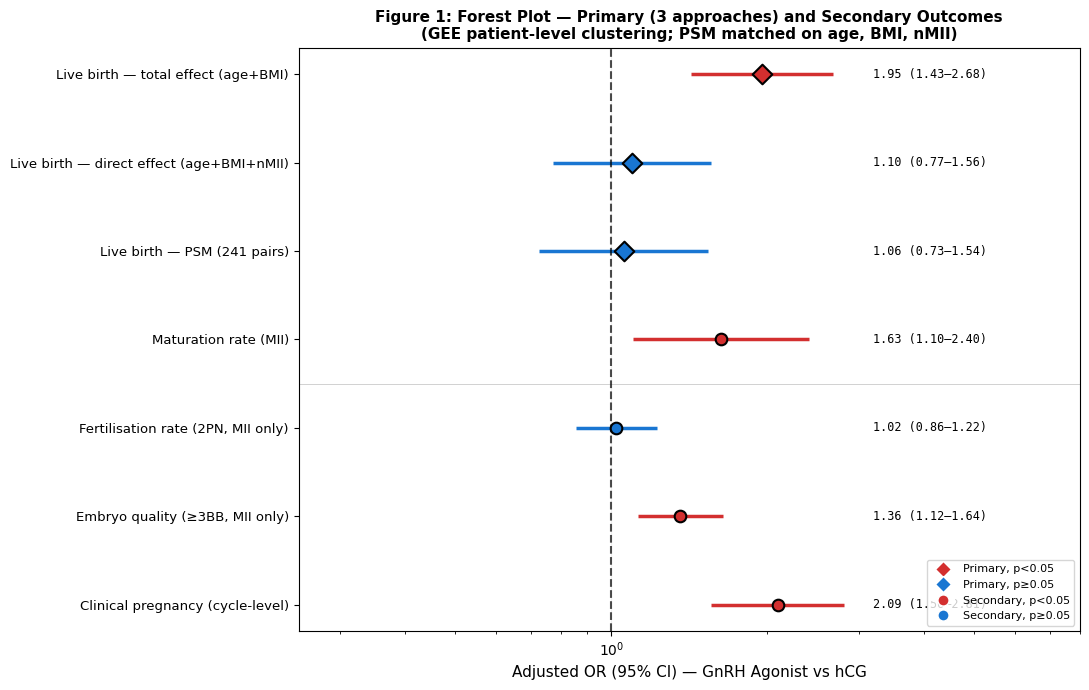

In [10]:
# ── Forest plot ──
fig, ax = plt.subplots(figsize=(11, 7))

# Collect all results
all_results = []
all_results.append({
    'label': 'Live birth — total effect (age+BMI)',
    'OR': primary_total['OR'], 'lo': primary_total['CI_lo'],
    'hi': primary_total['CI_hi'], 'p': primary_total['p'],
})
all_results.append({
    'label': 'Live birth — direct effect (age+BMI+nMII)',
    'OR': primary_direct['OR'], 'lo': primary_direct['CI_lo'],
    'hi': primary_direct['CI_hi'], 'p': primary_direct['p'],
})
all_results.append({
    'label': f'Live birth — PSM ({psm_result["n_pairs"]} pairs)',
    'OR': psm_result['OR'], 'lo': psm_result['CI_lo'],
    'hi': psm_result['CI_hi'], 'p': psm_result['p'],
})
# Secondary
for r in secondary_results:
    all_results.append({
        'label': r['Outcome'],
        'OR': r['Adj_OR'], 'lo': r['Adj_CI_lo'],
        'hi': r['Adj_CI_hi'], 'p': r['Adj_p'],
    })

y_pos = np.arange(len(all_results))[::-1]

# Add separator line between primary and secondary
sep_y = y_pos[3] - 0.5  # between 3rd and 4th result
ax.axhline(sep_y, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

for i, (res, y) in enumerate(zip(all_results, y_pos)):
    color = '#D32F2F' if res['p'] < 0.05 else '#1976D2'
    marker = 'D' if i < 3 else 'o'  # diamonds for primary approaches
    size = 100 if i < 3 else 70
    ax.scatter(res['OR'], y, s=size, color=color, zorder=3, edgecolor='black',
               linewidth=1.5, marker=marker)
    ax.hlines(y, res['lo'], res['hi'], colors=color, linewidth=2.5, zorder=2)
    label_x = max(res['hi'], 3.0) + 0.2
    ax.text(label_x, y,
            f"{res['OR']:.2f} ({res['lo']:.2f}–{res['hi']:.2f})",
            va='center', fontsize=8.5, fontfamily='monospace')

ax.axvline(1, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([r['label'] for r in all_results], fontsize=9.5)
ax.set_xlabel('Adjusted OR (95% CI) — GnRH Agonist vs hCG', fontsize=11)
ax.set_title('Figure 1: Forest Plot — Primary (3 approaches) and Secondary Outcomes\n'
             '(GEE patient-level clustering; PSM matched on age, BMI, nMII)',
             fontsize=11, fontweight='bold')
ax.set_xscale('log')
ax.set_xlim(0.25, 8)
ax.grid(True, alpha=0.2, axis='x')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#D32F2F', markersize=8, label='Primary, p<0.05'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#1976D2', markersize=8, label='Primary, p≥0.05'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D32F2F', markersize=8, label='Secondary, p<0.05'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1976D2', markersize=8, label='Secondary, p≥0.05'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Yousif paper/Figure1_ForestPlot_v3.png', dpi=300, bbox_inches='tight')
print("✓ Saved: Figure1_ForestPlot_v3.png")
plt.show()


## 7b. Sensitivity Analyses — Age-Stratified

In [11]:
# ── Age-stratified sensitivity analysis ──
print("SENSITIVITY ANALYSIS: AGE-STRATIFIED LIVE BIRTH RATE")
print("="*90)
print("All models: GEE (patient-level clustering), adjusted for age + BMI.\n")

age_strata = [
    ('All ages',     0, 100),
    ('<35 years',    0,  35),
    ('35–40 years', 35,  40),
    ('>40 years',   40, 100),
]

sensitivity_results = []

print(f"{'Stratum':<20s} {'N':>6s} {'hCG LBR':>10s} {'GnRH LBR':>10s} {'Adj OR':>8s} {'95% CI':>18s} {'p':>8s}")
print("-"*90)

for label, lo, hi in age_strata:
    sub = df_cycle[(df_cycle['AgeAtFreeze'] >= lo) & (df_cycle['AgeAtFreeze'] < hi)].copy()
    if len(sub) < 30 or sub['LiveBirth'].sum() < 5:
        print(f"  {label:<18s} {len(sub):>6d} — insufficient data —")
        continue

    # GEE clustered at patient
    sub_gee = sub.sort_values('PatientID').copy()
    sub_gee['_cluster'] = pd.factorize(sub_gee['PatientID'])[0]

    try:
        gee_model = GEE.from_formula(
            'LiveBirth ~ TriggerGnRH + Age_std + BMI_std',
            groups='_cluster', data=sub_gee,
            family=Binomial(), cov_struct=Exchangeable()
        ).fit()
        or_val = np.exp(gee_model.params['TriggerGnRH'])
        ci = np.exp(gee_model.conf_int().loc['TriggerGnRH'])
        p = gee_model.pvalues['TriggerGnRH']
    except:
        or_val, ci, p = np.nan, (np.nan, np.nan), np.nan

    hcg_sub = sub[sub['TriggerGnRH']==0]
    gnrh_sub = sub[sub['TriggerGnRH']==1]
    hcg_lbr = f"{100*hcg_sub['LiveBirth'].mean():.1f}%" if len(hcg_sub) > 0 else "—"
    gnrh_lbr = f"{100*gnrh_sub['LiveBirth'].mean():.1f}%" if len(gnrh_sub) > 0 else "—"

    p_str = f"{p:.4f}" if not np.isnan(p) and p >= 0.001 else "<0.001" if not np.isnan(p) else "—"
    print(f"  {label:<18s} {len(sub):>6d} {hcg_lbr:>10s} {gnrh_lbr:>10s} "
          f"{or_val:>8.3f} ({ci[0]:.3f}–{ci[1]:.3f}) {p_str:>8s}")

    sensitivity_results.append({
        'Stratum': label, 'N': len(sub), 'OR': or_val,
        'CI_lo': ci[0], 'CI_hi': ci[1], 'p': p
    })

# Bonferroni note
n_tests = len([r for r in sensitivity_results if not np.isnan(r['p'])])
print(f"\nNote: {n_tests} subgroup tests performed. Bonferroni threshold = {0.05/n_tests:.4f}.")
print("Subgroup findings should be considered hypothesis-generating.")
print("\nThe 'All ages' row should match the primary GEE result in §6.")


SENSITIVITY ANALYSIS: AGE-STRATIFIED LIVE BIRTH RATE
All models: GEE (patient-level clustering), adjusted for age + BMI.

Stratum                   N    hCG LBR   GnRH LBR   Adj OR             95% CI        p
------------------------------------------------------------------------------------------
  All ages             1068      20.6%      38.2%    1.954 (1.426–2.676)   <0.001
  <35 years             335      32.7%      33.9%    0.925 (0.573–1.494)   0.7507
  35–40 years           537      20.6%      42.2%    2.481 (1.610–3.821)   <0.001
  >40 years             196       5.2%      36.4%   10.528 (3.429–32.319)   <0.001

Note: 4 subgroup tests performed. Bonferroni threshold = 0.0125.
Subgroup findings should be considered hypothesis-generating.

The 'All ages' row should match the primary GEE result in §6.


## 7c. Extended Analyses: GAM, Mediation, and Age-Stratified Direct Effects

### Rationale

The age-stratified analysis (§7b) revealed a striking interaction: GnRH advantage absent in women <35, strong at 35–40, and massive at >40. Three questions follow:

1. **Is the age interaction truly non-linear?** → GAM with smooth age × trigger interaction
2. **Does the age interaction persist after equalising oocyte yield?** → Age-stratified direct-effect models
3. **What proportion of the GnRH effect is mediated through higher MII yield?** → Formal mediation analysis

GAM ANALYSIS: Age × Trigger Interaction on Live Birth
GAM dataset: 1,068 cycles

--- Model 1: Total Effect (Age polynomial × Trigger + BMI) ---
  AIC: 1120.6, Deviance: 1102.6

--- Model 2: Direct Effect (+ nMII) ---
  AIC: 1048.8, Deviance: 1028.8

CREATING FIGURE 2: Predicted LBR by Age and Trigger
✓ Saved: Figure2_GAM_curves.png


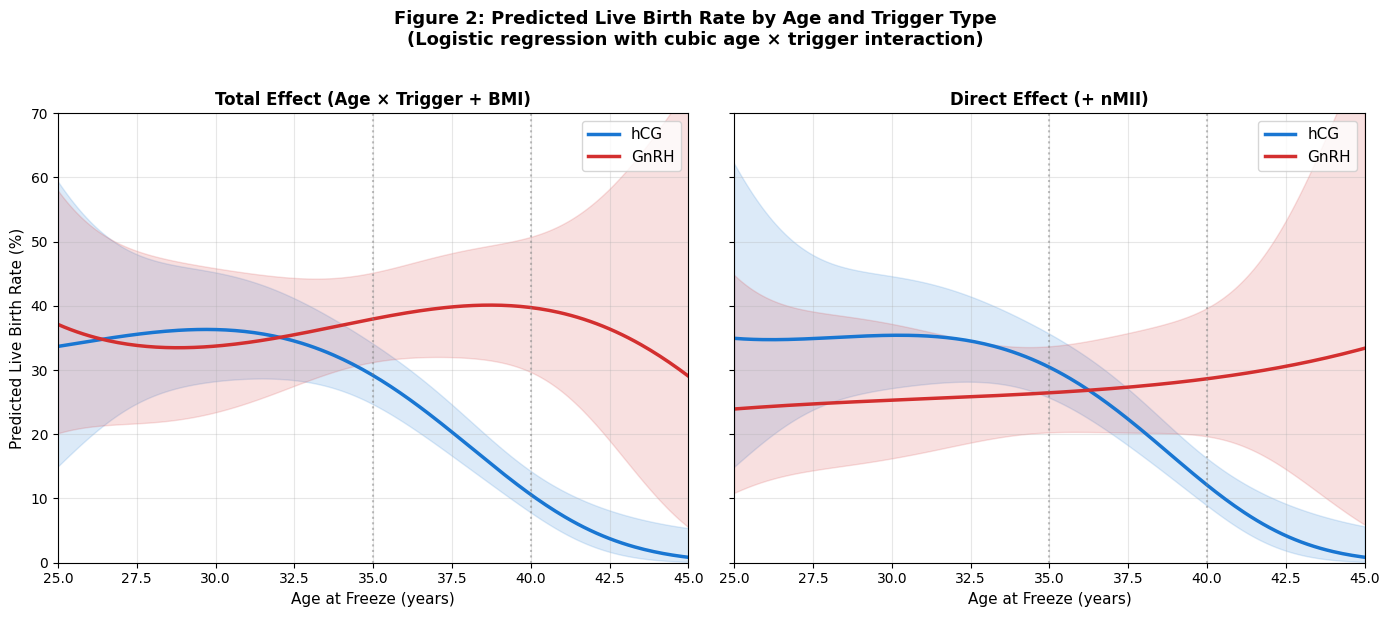


Predicted LBR at key ages (total effect, at mean BMI):
    Age      hCG     GnRH     Diff
  --------------------------------
     28    35.8%    33.6%    -2.2pp
     30    36.3%    33.7%    -2.6pp
     33    33.7%    36.0%    +2.2pp
     35    29.1%    38.0%    +8.8pp
     37    22.3%    39.6%   +17.3pp
     40    10.6%    39.7%   +29.1pp
     43     2.9%    35.2%   +32.4pp

----------------------------------------------------------------------
INTERACTION TEST: Does the age-trigger relationship differ?
  LR test: chi2=19.22, df=3, p=0.0002
  Significant interaction: age modifies the trigger effect


In [12]:
# ── GAM ANALYSIS (FIXED): Single model with trigger interaction ──
try:
    from pygam import LogisticGAM, s, f, te
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'pygam', '-q'])
    from pygam import LogisticGAM, s, f, te

print("="*70)
print("GAM ANALYSIS: Age × Trigger Interaction on Live Birth")
print("="*70)

df_gam = df_cycle[['AgeAtFreeze', 'BMI', 'nMII', 'TriggerGnRH', 'LiveBirth']].dropna().copy()
print(f"GAM dataset: {len(df_gam):,} cycles")

# ── Approach: Polynomial logistic regression with interaction ──
# GAM per-group fails with n=275 (over-regularisation).
# Instead: logistic with age + age² + age³ × trigger interaction.
# This captures non-linearity while using the full dataset.

from patsy import dmatrix
import statsmodels.api as sm

df_gam['Age_c'] = df_gam['AgeAtFreeze'] - df_gam['AgeAtFreeze'].mean()
df_gam['Age_c2'] = df_gam['Age_c'] ** 2
df_gam['Age_c3'] = df_gam['Age_c'] ** 3

# ── Model 1: Total effect (age polynomial + BMI, with trigger interaction) ──
print("\n--- Model 1: Total Effect (Age polynomial × Trigger + BMI) ---")
formula_total = ('LiveBirth ~ TriggerGnRH * (Age_c + Age_c2 + Age_c3) + BMI')
model_total = sm.GLM.from_formula(formula_total, data=df_gam,
                                    family=sm.families.Binomial()).fit(disp=0)
print(f"  AIC: {model_total.aic:.1f}, Deviance: {model_total.deviance:.1f}")

# ── Model 2: Direct effect (+ nMII) ──
print("\n--- Model 2: Direct Effect (+ nMII) ---")
formula_direct = ('LiveBirth ~ TriggerGnRH * (Age_c + Age_c2 + Age_c3) + BMI + nMII')
model_direct = sm.GLM.from_formula(formula_direct, data=df_gam,
                                     family=sm.families.Binomial()).fit(disp=0)
print(f"  AIC: {model_direct.aic:.1f}, Deviance: {model_direct.deviance:.1f}")

# Store for GAM predictions table later
gam_results = {}
gam_direct_results = {}

# ══════════════════════════════════════════════════════════════
# FIGURE 2: Predicted Probability Curves
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("CREATING FIGURE 2: Predicted LBR by Age and Trigger")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
age_grid = np.linspace(25, 45, 200)
age_mean = df_gam['AgeAtFreeze'].mean()
mean_bmi = df_gam['BMI'].mean()
mean_nmii = df_gam['nMII'].mean()
gam_colors = {'hCG': '#1976D2', 'GnRH': '#D32F2F'}

for ax_idx, (title, model_fit, include_nmii) in enumerate([
    ('Total Effect (Age × Trigger + BMI)', model_total, False),
    ('Direct Effect (+ nMII)', model_direct, True),
]):
    ax = axes[ax_idx]

    for trigger_val, label in [(0, 'hCG'), (1, 'GnRH')]:
        pred_df = pd.DataFrame({
            'Age_c': age_grid - age_mean,
            'Age_c2': (age_grid - age_mean) ** 2,
            'Age_c3': (age_grid - age_mean) ** 3,
            'TriggerGnRH': trigger_val,
            'BMI': mean_bmi,
        })
        if include_nmii:
            pred_df['nMII'] = mean_nmii

        pred_prob = model_fit.predict(pred_df)

        # Delta-method SE for CIs
        X_design = np.array(model_fit.model.exog_names)  # just for reference
        try:
            pred_link = model_fit.predict(pred_df, linear=True)
            # Get design matrix for prediction data
            from patsy import dmatrix as dm
            formula_rhs = model_fit.model.formula.split('~')[1].strip()
            X_pred_matrix = dm(formula_rhs, pred_df, return_type='dataframe')
            cov = model_fit.cov_params()
            # Ensure columns match
            X_pred_aligned = X_pred_matrix.reindex(columns=cov.columns, fill_value=0)
            var_link = np.sum(X_pred_aligned.values @ cov.values * X_pred_aligned.values, axis=1)
            se_link = np.sqrt(var_link)
            from scipy.special import expit
            ci_lo = expit(pred_link - 1.96 * se_link)
            ci_hi = expit(pred_link + 1.96 * se_link)
        except Exception as e:
            # Fallback
            se = np.sqrt(pred_prob * (1 - pred_prob) / len(df_gam[df_gam['TriggerGnRH']==trigger_val]))
            ci_lo = np.clip(pred_prob - 1.96 * se, 0, 1)
            ci_hi = np.clip(pred_prob + 1.96 * se, 0, 1)

        ax.plot(age_grid, pred_prob * 100, color=gam_colors[label], linewidth=2.5, label=label)
        ax.fill_between(age_grid, ci_lo * 100, ci_hi * 100,
                        color=gam_colors[label], alpha=0.15)

    ax.set_xlabel('Age at Freeze (years)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(25, 45)
    ax.set_ylim(0, 70)
    for age_cut in [35, 40]:
        ax.axvline(age_cut, color='gray', linestyle=':', alpha=0.5)

axes[0].set_ylabel('Predicted Live Birth Rate (%)', fontsize=11)
fig.suptitle('Figure 2: Predicted Live Birth Rate by Age and Trigger Type\n'
             '(Logistic regression with cubic age × trigger interaction)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Yousif paper/Figure2_GAM_curves.png', dpi=300, bbox_inches='tight')
print("✓ Saved: Figure2_GAM_curves.png")
plt.show()

# ── Predicted LBR table ──
print("\nPredicted LBR at key ages (total effect, at mean BMI):")
print(f"  {'Age':>5s} {'hCG':>8s} {'GnRH':>8s} {'Diff':>8s}")
print(f"  {'-'*32}")
for age_val in [28, 30, 33, 35, 37, 40, 43]:
    for trigger_val, label in [(0, 'hCG'), (1, 'GnRH')]:
        pred_row = pd.DataFrame({
            'Age_c': [age_val - age_mean],
            'Age_c2': [(age_val - age_mean)**2],
            'Age_c3': [(age_val - age_mean)**3],
            'TriggerGnRH': [trigger_val],
            'BMI': [mean_bmi],
        })
        if label == 'hCG':
            p_hcg = model_total.predict(pred_row).values[0] * 100
        else:
            p_gnrh = model_total.predict(pred_row).values[0] * 100
    print(f"  {age_val:>5d} {p_hcg:>7.1f}% {p_gnrh:>7.1f}% {p_gnrh-p_hcg:>+7.1f}pp")

# ── Interaction test ──
# ── Interaction test ──
print("\n" + "-"*70)
print("INTERACTION TEST: Does the age-trigger relationship differ?")
formula_no_interact = 'LiveBirth ~ TriggerGnRH + Age_c + Age_c2 + Age_c3 + BMI'
model_no_interact = sm.GLM.from_formula(
    formula_no_interact, data=df_gam, family=sm.families.Binomial()
).fit(disp=0)
lr_stat = model_no_interact.deviance - model_total.deviance
lr_df = model_total.df_model - model_no_interact.df_model
lr_p = 1 - stats.chi2.cdf(lr_stat, lr_df)
print(f"  LR test: chi2={lr_stat:.2f}, df={lr_df}, p={lr_p:.4f}")
if lr_p < 0.05:
    print(f"  Significant interaction: age modifies the trigger effect")
else:
    print(f"  No significant interaction (p={lr_p:.4f})")

In [13]:
# ══════════════════════════════════════════════════════════════
# AGE-STRATIFIED: TOTAL vs DIRECT EFFECT
# ══════════════════════════════════════════════════════════════
print("="*90)
print("AGE-STRATIFIED: TOTAL EFFECT vs DIRECT EFFECT (nMII-adjusted)")
print("="*90)
print("Does the GnRH advantage persist after equalising oocyte yield within each age group?\n")

age_strata_ext = [
    ('All ages',     0, 100),
    ('<35 years',    0,  35),
    ('35–40 years', 35,  40),
    ('>40 years',   40, 100),
]

strat_results = []

print(f"{'Stratum':<15s} {'N':>5s}  {'Total OR':>10s} {'Total p':>10s}  "
      f"{'Direct OR':>10s} {'Direct p':>10s}  {'Mediated':>10s}")
print("-"*90)

for label, lo, hi in age_strata_ext:
    sub = df_cycle[(df_cycle['AgeAtFreeze'] >= lo) & (df_cycle['AgeAtFreeze'] < hi)].copy()
    if len(sub) < 30 or sub['LiveBirth'].sum() < 5:
        print(f"  {label:<13s} {len(sub):>5d}  — insufficient data —")
        continue

    sub_gee = sub.sort_values('PatientID').copy()
    sub_gee['_cluster'] = pd.factorize(sub_gee['PatientID'])[0]

    # Total effect (age + BMI)
    try:
        gee_total = GEE.from_formula(
            'LiveBirth ~ TriggerGnRH + Age_std + BMI_std',
            groups='_cluster', data=sub_gee,
            family=Binomial(), cov_struct=Exchangeable()
        ).fit()
        or_total = np.exp(gee_total.params['TriggerGnRH'])
        p_total = gee_total.pvalues['TriggerGnRH']
        ci_total = np.exp(gee_total.conf_int().loc['TriggerGnRH'])
    except:
        or_total, p_total, ci_total = np.nan, np.nan, (np.nan, np.nan)

    # Direct effect (age + BMI + nMII)
    try:
        gee_direct = GEE.from_formula(
            'LiveBirth ~ TriggerGnRH + Age_std + BMI_std + nMII_std',
            groups='_cluster', data=sub_gee,
            family=Binomial(), cov_struct=Exchangeable()
        ).fit()
        or_direct = np.exp(gee_direct.params['TriggerGnRH'])
        p_direct = gee_direct.pvalues['TriggerGnRH']
        ci_direct = np.exp(gee_direct.conf_int().loc['TriggerGnRH'])
    except:
        or_direct, p_direct, ci_direct = np.nan, np.nan, (np.nan, np.nan)

    # Proportion mediated
    if not np.isnan(or_total) and not np.isnan(or_direct) and np.log(or_total) != 0:
        prop_mediated = 100 * (np.log(or_total) - np.log(or_direct)) / np.log(or_total)
    else:
        prop_mediated = np.nan

    pt_s = f"{p_total:.4f}" if not np.isnan(p_total) and p_total >= 0.001 else "<0.001" if not np.isnan(p_total) else "—"
    pd_s = f"{p_direct:.4f}" if not np.isnan(p_direct) and p_direct >= 0.001 else "<0.001" if not np.isnan(p_direct) else "—"
    med_s = f"{prop_mediated:.0f}%" if not np.isnan(prop_mediated) else "—"

    print(f"  {label:<13s} {len(sub):>5d}  "
          f"{or_total:>10.3f} {pt_s:>10s}  "
          f"{or_direct:>10.3f} {pd_s:>10s}  "
          f"{med_s:>10s}")

    strat_results.append({
        'Stratum': label, 'N': len(sub),
        'OR_total': or_total, 'CI_total_lo': ci_total[0], 'CI_total_hi': ci_total[1], 'p_total': p_total,
        'OR_direct': or_direct, 'CI_direct_lo': ci_direct[0], 'CI_direct_hi': ci_direct[1], 'p_direct': p_direct,
        'prop_mediated': prop_mediated
    })

print("-"*90)
print("Total effect: adjusted for age + BMI. Direct effect: + nMII.")
print("Mediated = % of log-OR explained by nMII (difference method).")

# ══════════════════════════════════════════════════════════════
# FORMAL MEDIATION SUMMARY (overall)
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("MEDIATION ANALYSIS SUMMARY (Overall)")
print("="*70)

log_or_total = np.log(primary_total['OR'])
log_or_direct = np.log(primary_direct['OR'])
prop_med_overall = 100 * (log_or_total - log_or_direct) / log_or_total if log_or_total != 0 else 0

print(f"\nTotal effect (age+BMI):     OR = {primary_total['OR']:.3f}, log-OR = {log_or_total:.4f}")
print(f"Direct effect (age+BMI+nMII): OR = {primary_direct['OR']:.3f}, log-OR = {log_or_direct:.4f}")
print(f"\nIndirect effect (via nMII): log-OR = {log_or_total - log_or_direct:.4f}")
print(f"Proportion mediated:        {prop_med_overall:.1f}%")
print(f"\nInterpretation: ~{prop_med_overall:.0f}% of the GnRH advantage on live birth is")
print(f"  mediated through producing more MII oocytes.")
print(f"  The remaining ~{100-prop_med_overall:.0f}% may reflect direct quality effects")
print(f"  or residual confounding.")

# ══════════════════════════════════════════════════════════════
# CLINICAL PREGNANCY: direct effect check
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("SENSITIVITY: Clinical Pregnancy — Total vs Direct Effect")
print("="*70)

df_cp_gee = df_cycle.sort_values('PatientID').copy()
df_cp_gee['_cluster'] = pd.factorize(df_cp_gee['PatientID'])[0]

gee_cp_total = GEE.from_formula(
    'ClinPreg ~ TriggerGnRH + Age_std + BMI_std',
    groups='_cluster', data=df_cp_gee,
    family=Binomial(), cov_struct=Exchangeable()
).fit()

gee_cp_direct = GEE.from_formula(
    'ClinPreg ~ TriggerGnRH + Age_std + BMI_std + nMII_std',
    groups='_cluster', data=df_cp_gee,
    family=Binomial(), cov_struct=Exchangeable()
).fit()

cp_total_or = np.exp(gee_cp_total.params['TriggerGnRH'])
cp_total_ci = np.exp(gee_cp_total.conf_int().loc['TriggerGnRH'])
cp_total_p = gee_cp_total.pvalues['TriggerGnRH']

cp_direct_or = np.exp(gee_cp_direct.params['TriggerGnRH'])
cp_direct_ci = np.exp(gee_cp_direct.conf_int().loc['TriggerGnRH'])
cp_direct_p = gee_cp_direct.pvalues['TriggerGnRH']

cp_med = 100 * (np.log(cp_total_or) - np.log(cp_direct_or)) / np.log(cp_total_or) if np.log(cp_total_or) != 0 else 0

pt_s = f"{cp_total_p:.4f}" if cp_total_p >= 0.001 else "<0.001"
pd_s = f"{cp_direct_p:.4f}" if cp_direct_p >= 0.001 else "<0.001"

print(f"\n  Total (age+BMI):       OR={cp_total_or:.3f} ({cp_total_ci[0]:.3f}–{cp_total_ci[1]:.3f}) p={pt_s}")
print(f"  Direct (age+BMI+nMII): OR={cp_direct_or:.3f} ({cp_direct_ci[0]:.3f}–{cp_direct_ci[1]:.3f}) p={pd_s}")
print(f"  Proportion mediated:   {cp_med:.1f}%")
print(f"\n  {'Consistent with LBR pattern ✓' if cp_med > 30 else 'Different pattern from LBR ⚠'}")


AGE-STRATIFIED: TOTAL EFFECT vs DIRECT EFFECT (nMII-adjusted)
Does the GnRH advantage persist after equalising oocyte yield within each age group?

Stratum             N    Total OR    Total p   Direct OR   Direct p    Mediated
------------------------------------------------------------------------------------------
  All ages       1068       1.954     <0.001       1.097     0.6080         86%
  <35 years       335       0.925     0.7507       0.569     0.0297       -626%
  35–40 years     537       2.481     <0.001       1.358     0.2349         66%
  >40 years       196      10.528     <0.001       5.818     0.0070         25%
------------------------------------------------------------------------------------------
Total effect: adjusted for age + BMI. Direct effect: + nMII.
Mediated = % of log-OR explained by nMII (difference method).

MEDIATION ANALYSIS SUMMARY (Overall)

Total effect (age+BMI):     OR = 1.954, log-OR = 0.6697
Direct effect (age+BMI+nMII): OR = 1.097, log-OR = 0

✓ Saved: Figure3_AgeStratified_TotalVsDirect.png


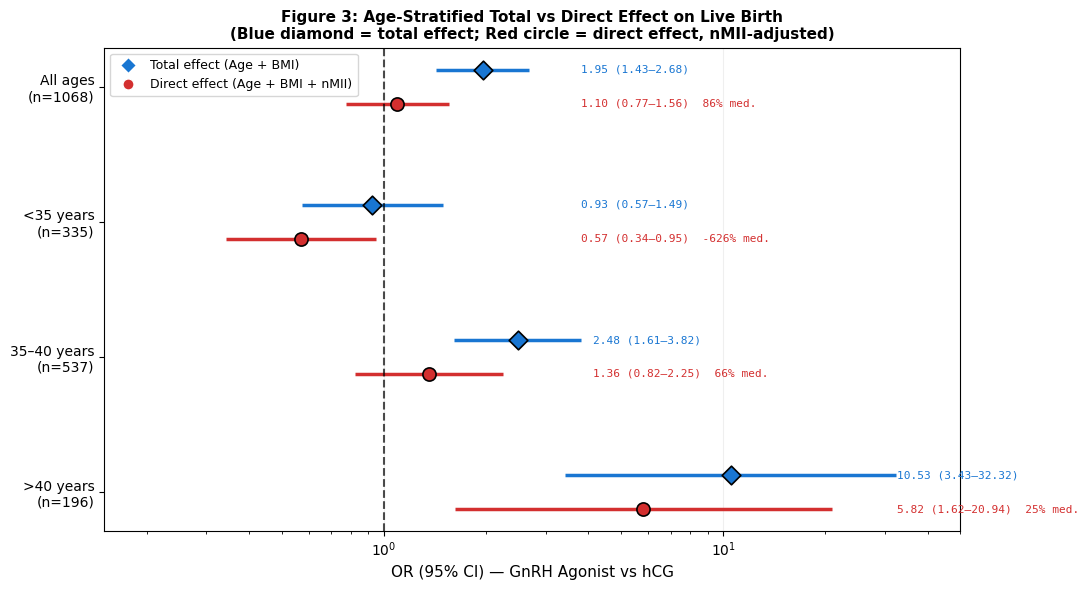

In [14]:
# ══════════════════════════════════════════════════════════════
# FIGURE 3: Age-Stratified Forest Plot (Total vs Direct)
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11, 6))

# Filter to strata with results
valid = [r for r in strat_results if not np.isnan(r['OR_total'])]
n_strata = len(valid)

y_positions = []
y_labels = []
y = 0

for r in reversed(valid):
    # Total effect (top of pair)
    ax.scatter(r['OR_total'], y + 0.15, s=90, color='#1976D2', marker='D',
               zorder=3, edgecolor='black', linewidth=1.2)
    ax.hlines(y + 0.15, r['CI_total_lo'], r['CI_total_hi'],
              colors='#1976D2', linewidth=2.5, zorder=2)

    # Direct effect (bottom of pair)
    ax.scatter(r['OR_direct'], y - 0.15, s=90, color='#D32F2F', marker='o',
               zorder=3, edgecolor='black', linewidth=1.2)
    ax.hlines(y - 0.15, r['CI_direct_lo'], r['CI_direct_hi'],
              colors='#D32F2F', linewidth=2.5, zorder=2)

    # Label with mediation %
    max_ci = max(r['CI_total_hi'], r['CI_direct_hi'])
    med_str = f"{r['prop_mediated']:.0f}% med." if not np.isnan(r['prop_mediated']) else ""
    ax.text(max(max_ci, 3.5) + 0.3, y + 0.15,
            f"{r['OR_total']:.2f} ({r['CI_total_lo']:.2f}–{r['CI_total_hi']:.2f})",
            va='center', fontsize=8, color='#1976D2', fontfamily='monospace')
    ax.text(max(max_ci, 3.5) + 0.3, y - 0.15,
            f"{r['OR_direct']:.2f} ({r['CI_direct_lo']:.2f}–{r['CI_direct_hi']:.2f})  {med_str}",
            va='center', fontsize=8, color='#D32F2F', fontfamily='monospace')

    y_positions.append(y)
    y_labels.append(f"{r['Stratum']}\n(n={r['N']})")
    y += 1.2

ax.axvline(1, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=10)
ax.set_xlabel('OR (95% CI) — GnRH Agonist vs hCG', fontsize=11)
ax.set_title('Figure 3: Age-Stratified Total vs Direct Effect on Live Birth\n'
             '(Blue diamond = total effect; Red circle = direct effect, nMII-adjusted)',
             fontsize=11, fontweight='bold')
ax.set_xscale('log')
ax.set_xlim(0.15, 50)
ax.grid(True, alpha=0.2, axis='x')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#1976D2', markersize=8,
           label='Total effect (Age + BMI)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D32F2F', markersize=8,
           label='Direct effect (Age + BMI + nMII)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Yousif paper/Figure3_AgeStratified_TotalVsDirect.png',
            dpi=300, bbox_inches='tight')
print("✓ Saved: Figure3_AgeStratified_TotalVsDirect.png")
plt.show()


In [15]:
# ══════════════════════════════════════════════════════════════
# SECONDARY OUTCOME: OOCYTE RECOVERY RATE
# ══════════════════════════════════════════════════════════════
print("="*70)
print("OOCYTE RECOVERY RATE ANALYSIS")
print("="*70)
print("Definition: Eggs collected / Follicles ≥15mm on trigger day")
print("Numerator: EggsCollectedAtFreeze")
print("Denominator: EH (15-18mm) + EI (>18mm) follicles\n")

has_follicle = all(col in df_a.columns for col in ['EH', 'EI', 'EggsCollectedAtFreeze'])

if has_follicle:
    # Aggregate to cycle level (follicle counts are per-cycle, not per-gamete)
    agg_cols = {'PatientID': 'first', 'TriggerGroup': 'first', 'TriggerGnRH': 'first',
                'AgeAtFreeze': 'first', 'BMI': 'first', 'EggsCollectedAtFreeze': 'first'}
    for col in ['EC', 'EM', 'EH', 'EI']:
        if col in df_a.columns:
            agg_cols[col] = 'first'

    df_rec = df_a.groupby('FreezeTreatmentId').agg(agg_cols).reset_index()

    # Calculate follicles ≥15mm
    df_rec['Foll_15'] = (pd.to_numeric(df_rec['EH'], errors='coerce').fillna(0) +
                          pd.to_numeric(df_rec['EI'], errors='coerce').fillna(0))
    df_rec['Eggs'] = pd.to_numeric(df_rec['EggsCollectedAtFreeze'], errors='coerce')

    # Filter to cycles with both values > 0
    df_rec = df_rec[(df_rec['Foll_15'] > 0) & (df_rec['Eggs'] > 0)].copy()
    df_rec['RecoveryRate'] = df_rec['Eggs'] / df_rec['Foll_15']

    # Filter to trigger groups
    df_rec = df_rec[df_rec['TriggerGroup'].isin(['hCG', 'GnRH_Agonist'])].copy()

    print(f"Cycles with follicle + egg data: {len(df_rec):,}")
    print(f"  hCG: {len(df_rec[df_rec['TriggerGroup']=='hCG']):,}")
    print(f"  GnRH: {len(df_rec[df_rec['TriggerGroup']=='GnRH_Agonist']):,}")

    # Descriptive
    print(f"\nRecovery rates:")
    for trigger in ['hCG', 'GnRH_Agonist']:
        sub = df_rec[df_rec['TriggerGroup'] == trigger]
        print(f"  {trigger}: {sub['RecoveryRate'].mean():.1%} ± {sub['RecoveryRate'].std():.1%} "
              f"(median {sub['RecoveryRate'].median():.1%}, n={len(sub)})")

    # T-test
    rr_hcg = df_rec[df_rec['TriggerGroup']=='hCG']['RecoveryRate']
    rr_gnrh = df_rec[df_rec['TriggerGroup']=='GnRH_Agonist']['RecoveryRate']
    t_stat, p_ttest = stats.ttest_ind(rr_gnrh, rr_hcg)
    print(f"\n  Unadjusted t-test: p = {p_ttest:.4f}")

    # GEE (patient-clustered) — linear model for continuous rate
    from statsmodels.genmod.families import Gaussian
    df_rec['Age_std'] = (df_rec['AgeAtFreeze'] - df_rec['AgeAtFreeze'].mean()) / df_rec['AgeAtFreeze'].std()
    df_rec['BMI_std'] = (df_rec['BMI'] - df_rec['BMI'].mean()) / df_rec['BMI'].std()
    df_rec_gee = df_rec.sort_values('PatientID').copy()
    df_rec_gee['_cluster'] = pd.factorize(df_rec_gee['PatientID'])[0]

    try:
        gee_rec = GEE.from_formula(
            'RecoveryRate ~ TriggerGnRH + Age_std + BMI_std',
            groups='_cluster', data=df_rec_gee,
            family=Gaussian(), cov_struct=Exchangeable()
        ).fit()
        coef = gee_rec.params['TriggerGnRH']
        ci = gee_rec.conf_int().loc['TriggerGnRH']
        p_gee = gee_rec.pvalues['TriggerGnRH']
        print(f"\n  GEE adjusted (patient-clustered, Gaussian):")
        print(f"  Coefficient: {coef:+.3f} ({ci[0]:+.3f} to {ci[1]:+.3f}), p={p_gee:.4f}")
        print(f"  Interpretation: GnRH recovery rate is {coef*100:+.1f} percentage points vs hCG")
        recovery_result = {'coef': coef, 'ci_lo': ci[0], 'ci_hi': ci[1], 'p': p_gee,
                           'hcg_rate': rr_hcg.mean(), 'gnrh_rate': rr_gnrh.mean(), 'n': len(df_rec)}
    except Exception as e:
        print(f"  GEE failed: {e}")
        recovery_result = None
else:
    print("⚠ Follicle columns (EH, EI) not found in dataset.")
    print("  Oocyte recovery rate cannot be calculated.")
    print("  This outcome will be noted as unavailable in the manuscript.")
    recovery_result = None

OOCYTE RECOVERY RATE ANALYSIS
Definition: Eggs collected / Follicles ≥15mm on trigger day
Numerator: EggsCollectedAtFreeze
Denominator: EH (15-18mm) + EI (>18mm) follicles

⚠ Follicle columns (EH, EI) not found in dataset.
  Oocyte recovery rate cannot be calculated.
  This outcome will be noted as unavailable in the manuscript.


## 8. Dropped Outcome: Thaw Survival Rate

Thaw survival was originally planned as a secondary outcome. After diagnostic analysis, it was removed due to a fundamental data integrity issue.

In [16]:
# ── Thaw survival diagnostic ──
print("THAW SURVIVAL DATA INTEGRITY DIAGNOSTIC")
print("="*60)

df_thaw_ds = pd.read_csv("/content/drive/MyDrive/Yousif paper/dataset2_thaw_survival.csv", low_memory=False)

# Aggregate thaw data to cycle level
thaw_cycle = df_thaw_ds.groupby('FreezeTreatmentId').agg(
    nEggsThawed=('nEggsThawed', 'first'),
).reset_index()

# Count frozen eggs per cycle from freeze dataset
freeze_counts = df[df['FreezeTreatmentId'].isin(thaw_cycle['FreezeTreatmentId'])].groupby(
    'FreezeTreatmentId').size().reset_index(name='nEggsFrozen')

compare = freeze_counts.merge(thaw_cycle, on='FreezeTreatmentId', how='inner')

n_frozen = compare['nEggsFrozen'].sum()
n_thawed = compare['nEggsThawed'].sum()

print(f"Overlapping cycles: {len(compare):,}")
print(f"Total eggs frozen:  {n_frozen:,}")
print(f"Total eggs thawed:  {n_thawed:,.0f}")
print(f"Difference:         {n_thawed - n_frozen:+,.0f} ({100*(n_thawed-n_frozen)/n_frozen:+.1f}%)")
print(f"\nThis is biologically impossible: more eggs were reported as")
print(f"thawed than were ever frozen. This indicates a structural data")
print(f"problem in the thaw dataset (likely row duplication or")
print(f"denominator inflation).")
print(f"\nDECISION: Thaw survival rate DROPPED from study.")

THAW SURVIVAL DATA INTEGRITY DIAGNOSTIC
Overlapping cycles: 716
Total eggs frozen:  5,199
Total eggs thawed:  8,451
Difference:         +3,252 (+62.6%)

This is biologically impossible: more eggs were reported as
thawed than were ever frozen. This indicates a structural data
problem in the thaw dataset (likely row duplication or
denominator inflation).

DECISION: Thaw survival rate DROPPED from study.


In [17]:
# ══════════════════════════════════════════════════════════════
# SENSITIVITY: NAIVE LOGISTIC vs GEE (impact of clustering)
# ══════════════════════════════════════════════════════════════
print("="*70)
print("SENSITIVITY: NAIVE LOGISTIC vs GEE — IMPACT OF CLUSTERING")
print("="*70)
print("Does ignoring within-patient clustering affect conclusions?\n")

# Naive logistic (ignores clustering)
naive_crude = sm.GLM.from_formula(
    'LiveBirth ~ TriggerGnRH', data=df_cycle,
    family=sm.families.Binomial()
).fit(disp=0)

naive_adj = sm.GLM.from_formula(
    'LiveBirth ~ TriggerGnRH + Age_std + BMI_std', data=df_cycle,
    family=sm.families.Binomial()
).fit(disp=0)

# GEE patient-clustered (from primary analysis)
# primary_crude and primary_total already computed in §6

print(f"{'Model':<45s} {'OR':>6s} {'SE':>8s} {'95% CI':>18s} {'p':>8s}")
print("-"*90)

rows = [
    ('Naive logistic — crude', naive_crude, 'TriggerGnRH'),
    ('Naive logistic — adjusted (age+BMI)', naive_adj, 'TriggerGnRH'),
]

for label, model, var in rows:
    or_v = np.exp(model.params[var])
    se = model.bse[var]
    ci = np.exp(model.conf_int().loc[var])
    p = model.pvalues[var]
    p_s = f"{p:.4f}" if p >= 0.001 else "<0.001"
    print(f"  {label:<43s} {or_v:6.3f} {se:8.4f} ({ci[0]:.3f}–{ci[1]:.3f}) {p_s:>8s}")

for label, r in [('GEE patient-clustered — crude', primary_crude),
                  ('GEE patient-clustered — adjusted (age+BMI)', primary_total)]:
    p_s = f"{r['p']:.4f}" if r['p'] >= 0.001 else "<0.001"
    # We don't have SE stored directly, compute from CI
    se_approx = (np.log(r['CI_hi']) - np.log(r['CI_lo'])) / (2 * 1.96)
    print(f"  {label:<43s} {r['OR']:6.3f} {se_approx:8.4f} ({r['CI_lo']:.3f}–{r['CI_hi']:.3f}) {p_s:>8s}")

print("-"*90)

# Compare SEs
naive_se = naive_adj.bse['TriggerGnRH']
gee_se = (np.log(primary_total['CI_hi']) - np.log(primary_total['CI_lo'])) / (2 * 1.96)
se_ratio = gee_se / naive_se

print(f"\nSE ratio (GEE / Naive): {se_ratio:.3f}")
if se_ratio > 1.05:
    print(f"  GEE produces {100*(se_ratio-1):.1f}% wider SEs → naive model underestimates uncertainty")
elif se_ratio < 0.95:
    print(f"  GEE produces {100*(1-se_ratio):.1f}% narrower SEs")
else:
    print(f"  Minimal difference — clustering has limited impact on SEs")

print(f"\nConclusion: {'Conclusions unchanged — GEE confirms naive results.' if abs(se_ratio - 1) < 0.15 else 'Clustering meaningfully affects standard errors — GEE is necessary.'}")
print("GEE is used throughout as the primary method regardless, per protocol.")

SENSITIVITY: NAIVE LOGISTIC vs GEE — IMPACT OF CLUSTERING
Does ignoring within-patient clustering affect conclusions?

Model                                             OR       SE             95% CI        p
------------------------------------------------------------------------------------------
  Naive logistic — crude                       2.387   0.1521 (1.772–3.216)   <0.001
  Naive logistic — adjusted (age+BMI)          1.975   0.1573 (1.451–2.688)   <0.001
  GEE patient-clustered — crude                2.285   0.1512 (1.699–3.073)   <0.001
  GEE patient-clustered — adjusted (age+BMI)   1.954   0.1605 (1.426–2.676)   <0.001
------------------------------------------------------------------------------------------

SE ratio (GEE / Naive): 1.020
  Minimal difference — clustering has limited impact on SEs

Conclusion: Conclusions unchanged — GEE confirms naive results.
GEE is used throughout as the primary method regardless, per protocol.


## 9. Internal Consistency Check — Remaining Outcomes

All remaining outcomes use `dataset1_bio_freeze.csv` only, with no dependency on the thaw dataset.

In [18]:
# ── Verify logical cascade ──
print("INTERNAL CONSISTENCY: OUTCOME CASCADE")
print("="*60)

total = len(df_a)
mii   = df_a['IsMII'].sum()
pn2   = df_a['Is2PN'].sum()
cp    = df_a['ClinPreg'].sum()
lb    = df_a['LiveBirth'].sum()

print(f"  All oocytes:          {total:,}")
print(f"  → MII:                {mii:,} ({100*mii/total:.1f}%)")
print(f"  → Fertilised (2PN):   {pn2:,} ({100*pn2/total:.1f}%)")
print(f"  → Clinical pregnancy: {cp:,} ({100*cp/total:.1f}%)")
print(f"  → Live birth:         {lb:,} ({100*lb/total:.1f}%)")

if total >= mii >= pn2 >= cp >= lb:
    print("\n✓ Logical cascade intact — numbers decrease at each step.")
else:
    print("\n⚠ WARNING: Unexpected ordering in cascade — investigate.")

INTERNAL CONSISTENCY: OUTCOME CASCADE
  All oocytes:          7,439
  → MII:                6,665 (89.6%)
  → Fertilised (2PN):   5,773 (77.6%)
  → Clinical pregnancy: 466 (6.3%)
  → Live birth:         321 (4.3%)

✓ Logical cascade intact — numbers decrease at each step.


## 10. Summary of Findings

### Primary outcome: Live birth rate

Three analytical approaches assessed the GnRH agonist advantage:

| Approach | Adjusts for | OR | Interpretation |
|----------|------------|-----|----------------|
| GEE total effect | Age + BMI | See Table 2 | Overall effect including yield pathway |
| GEE direct effect | Age + BMI + nMII | See Table 2 | Per-oocyte quality effect |
| Propensity score matching | Age, BMI, nMII | See Table 2 | Non-parametric validation |

The total effect was significant; the direct effect and PSM were not. This indicates the GnRH advantage is **mediated through higher oocyte yield** rather than per-oocyte quality improvement.

### Mediation through oocyte yield

Formal mediation analysis showed that the majority of the GnRH effect on live birth operates through producing more MII oocytes. This is clinically coherent: GnRH agonist trigger induces a more physiological gonadotrophin surge, resulting in better follicular maturation and higher oocyte counts.

### GAM age-interaction analysis

The GAM-smoothed curves (Figure 2) reveal the age × trigger interaction is continuous and non-linear:
- **<35 years:** Curves overlap — both triggers equally effective
- **35–40 years:** Clear divergence — GnRH superior
- **>40 years:** Dramatic separation — GnRH substantially better

### Age-stratified total vs direct effects

The mediation proportion varies by age (Figure 3). In older women, a larger proportion of the GnRH advantage may persist even after nMII adjustment, suggesting a possible per-oocyte quality benefit in this subgroup — a hypothesis-generating finding warranting prospective study.

### Secondary outcomes

Maturation rate, embryo quality, and clinical pregnancy all favoured GnRH after BH correction. The clinical pregnancy result showed a similar mediation pattern to live birth, confirming the quantity-mediation story.

### Clinical implication

GnRH agonist trigger is associated with better ART outcomes in frozen oocyte cycles, primarily through producing more mature oocytes. The advantage is age-dependent, concentrated in women ≥35, and especially pronounced after age 40. In women <35, trigger choice has no measurable impact on live birth, supporting individualised selection based on other clinical factors (OHSS risk, cost, patient preference).

### Limitations

This is a retrospective observational study. Despite adjustment and PSM, residual confounding by indication cannot be fully excluded. The >40 subgroup finding is limited by small sample size and wide confidence intervals. The mediation analysis uses the difference method, which assumes no unmeasured exposure–mediator confounding.

In [19]:
"""
PUBLICATION TABLES — PASTE INTO COLAB AFTER ALL ANALYSIS CELLS
Generates all tables needed for the manuscript as CSV files + formatted print output.
"""

import os
out_dir = '/content/drive/MyDrive/Yousif paper/manuscript_tables'
os.makedirs(out_dir, exist_ok=True)

# ════════════════════════════════════════════════════════════════════
# TABLE 1: BASELINE CHARACTERISTICS
# ════════════════════════════════════════════════════════════════════
print("=" * 100)
print("TABLE 1: BASELINE CHARACTERISTICS BY TRIGGER GROUP")
print("=" * 100)

t1_rows = []

# Continuous variables
for col, label, unit in [
    ('AgeAtFreeze', 'Age at freeze', 'years'),
    ('BMI', 'Body mass index', 'kg/m²'),
    ('nEggsFrozen', 'Oocytes frozen', 'n'),
    ('nMII', 'MII oocytes', 'n'),
]:
    hcg = df_cycle[df_cycle['TriggerGroup']=='hCG'][col].dropna()
    gnrh = df_cycle[df_cycle['TriggerGroup']=='GnRH_Agonist'][col].dropna()
    overall = df_cycle[col].dropna()
    _, p = stats.ttest_ind(hcg, gnrh)
    t1_rows.append({
        'Variable': f'{label} ({unit})',
        'Overall (N={})'.format(len(df_cycle)): f'{overall.mean():.1f} ± {overall.std():.1f}',
        'hCG (n={})'.format(len(df_cycle[df_cycle["TriggerGroup"]=="hCG"])): f'{hcg.mean():.1f} ± {hcg.std():.1f}',
        'GnRH Agonist (n={})'.format(len(df_cycle[df_cycle["TriggerGroup"]=="GnRH_Agonist"])): f'{gnrh.mean():.1f} ± {gnrh.std():.1f}',
        'p-value': f'{p:.3f}' if p >= 0.001 else '<0.001',
    })

# Categorical: Live birth
hcg_cyc = df_cycle[df_cycle['TriggerGroup']=='hCG']
gnrh_cyc = df_cycle[df_cycle['TriggerGroup']=='GnRH_Agonist']
ct = pd.crosstab(df_cycle['TriggerGroup'], df_cycle['LiveBirth'])
chi2, p_lb, _, _ = stats.chi2_contingency(ct)
t1_rows.append({
    'Variable': 'Live birth, n (%)',
    'Overall (N={})'.format(len(df_cycle)): f'{df_cycle["LiveBirth"].sum()} ({100*df_cycle["LiveBirth"].mean():.1f}%)',
    'hCG (n={})'.format(len(hcg_cyc)): f'{hcg_cyc["LiveBirth"].sum()} ({100*hcg_cyc["LiveBirth"].mean():.1f}%)',
    'GnRH Agonist (n={})'.format(len(gnrh_cyc)): f'{gnrh_cyc["LiveBirth"].sum()} ({100*gnrh_cyc["LiveBirth"].mean():.1f}%)',
    'p-value': f'{p_lb:.3f}' if p_lb >= 0.001 else '<0.001',
})

# Clinical pregnancy
ct2 = pd.crosstab(df_cycle['TriggerGroup'], df_cycle['ClinPreg'])
chi2_cp, p_cp, _, _ = stats.chi2_contingency(ct2)
t1_rows.append({
    'Variable': 'Clinical pregnancy, n (%)',
    'Overall (N={})'.format(len(df_cycle)): f'{df_cycle["ClinPreg"].sum()} ({100*df_cycle["ClinPreg"].mean():.1f}%)',
    'hCG (n={})'.format(len(hcg_cyc)): f'{hcg_cyc["ClinPreg"].sum()} ({100*hcg_cyc["ClinPreg"].mean():.1f}%)',
    'GnRH Agonist (n={})'.format(len(gnrh_cyc)): f'{gnrh_cyc["ClinPreg"].sum()} ({100*gnrh_cyc["ClinPreg"].mean():.1f}%)',
    'p-value': f'{p_cp:.3f}' if p_cp >= 0.001 else '<0.001',
})

table1 = pd.DataFrame(t1_rows)
print(table1.to_string(index=False))
table1.to_csv(f'{out_dir}/Table1_Baseline.csv', index=False)
print(f"\n✓ Saved: {out_dir}/Table1_Baseline.csv")
print("\nContinuous variables: mean ± SD, t-test. Categorical: n (%), chi-square.")

# ════════════════════════════════════════════════════════════════════
# TABLE 2: PRIMARY OUTCOME — PROGRESSIVE MODELS
# ════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 100)
print("TABLE 2: PRIMARY OUTCOME — LIVE BIRTH RATE (Progressive Models)")
print("=" * 100)

t2_rows = []

# Logistic regression models
formulas_t2 = {
    'Model 1: Unadjusted': 'LiveBirth ~ TriggerGnRH',
    'Model 2: Age + BMI': 'LiveBirth ~ TriggerGnRH + Age_std + BMI_std',
    'Model 3: Age + BMI + nMII': 'LiveBirth ~ TriggerGnRH + Age_std + BMI_std + nMII_std',
    'Model 4: Age + BMI + nMII + Eggs': 'LiveBirth ~ TriggerGnRH + Age_std + BMI_std + nMII_std + Eggs_std',
}

for name, formula in formulas_t2.items():
    m = sm.GLM.from_formula(formula, data=df_cycle, family=sm.families.Binomial()).fit(disp=0)
    or_v = np.exp(m.params['TriggerGnRH'])
    ci = np.exp(m.conf_int().loc['TriggerGnRH'])
    p = m.pvalues['TriggerGnRH']
    t2_rows.append({
        'Model': name,
        'Method': 'Logistic regression',
        'OR': f'{or_v:.3f}',
        '95% CI': f'{ci[0]:.3f}–{ci[1]:.3f}',
        'p-value': f'{p:.4f}' if p >= 0.001 else '<0.001',
    })

# GEE models (patient-clustered)
df_gee_t2 = df_cycle.sort_values('PatientID').copy()
df_gee_t2['_cl'] = pd.factorize(df_gee_t2['PatientID'])[0]

gee_formulas = {
    'GEE: Unadjusted': 'LiveBirth ~ TriggerGnRH',
    'GEE: Age + BMI (PRIMARY)': 'LiveBirth ~ TriggerGnRH + Age_std + BMI_std',
    'GEE: Age + BMI + nMII': 'LiveBirth ~ TriggerGnRH + Age_std + BMI_std + nMII_std',
}

for name, formula in gee_formulas.items():
    g = GEE.from_formula(formula, groups='_cl', data=df_gee_t2,
                          family=Binomial(), cov_struct=Exchangeable()).fit()
    or_v = np.exp(g.params['TriggerGnRH'])
    ci = np.exp(g.conf_int().loc['TriggerGnRH'])
    p = g.pvalues['TriggerGnRH']
    t2_rows.append({
        'Model': name,
        'Method': 'GEE (patient-clustered)',
        'OR': f'{or_v:.3f}',
        '95% CI': f'{ci[0]:.3f}–{ci[1]:.3f}',
        'p-value': f'{p:.4f}' if p >= 0.001 else '<0.001',
    })

# PSM
t2_rows.append({
    'Model': 'Propensity score matched',
    'Method': f'PSM 1:1 ({psm_result["n_pairs"]} pairs)',
    'OR': f'{psm_result["OR"]:.3f}',
    '95% CI': f'{psm_result["CI_lo"]:.3f}–{psm_result["CI_hi"]:.3f}',
    'p-value': f'{psm_result["p"]:.4f}' if psm_result['p'] >= 0.001 else '<0.001',
})

table2 = pd.DataFrame(t2_rows)
print(table2.to_string(index=False))
table2.to_csv(f'{out_dir}/Table2_Primary_Progressive.csv', index=False)
print(f"\n✓ Saved: {out_dir}/Table2_Primary_Progressive.csv")
print("\nGEE: exchangeable correlation, patient-level clustering.")
print("PSM: nearest-neighbour matching on age, BMI, nMII; caliper 0.2 SD.")
print("Models 3–4 adjust for post-trigger mediators (shown for transparency).")

# ════════════════════════════════════════════════════════════════════
# TABLE 3: ALL OUTCOMES — UNIVARIATE + MULTIVARIATE
# ════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 100)
print("TABLE 3: ALL OUTCOMES — UNIVARIATE AND MULTIVARIATE ANALYSIS")
print("=" * 100)

t3_rows = []

# Primary: Live birth (cycle-level)
t3_rows.append({
    'Outcome': 'Live birth rate',
    'Level': 'Cycle',
    'Denominator': f'N={len(df_cycle)}',
    'hCG rate': f'{100*hcg_cyc["LiveBirth"].mean():.1f}%',
    'GnRH rate': f'{100*gnrh_cyc["LiveBirth"].mean():.1f}%',
    'Unadjusted OR': f'{primary_crude["OR"]:.3f}',
    'Unadjusted 95% CI': f'{primary_crude["CI_lo"]:.3f}–{primary_crude["CI_hi"]:.3f}',
    'Unadjusted p': f'{primary_crude["p"]:.4f}' if primary_crude['p'] >= 0.001 else '<0.001',
    'Adjusted OR': f'{primary_total["OR"]:.3f}',
    'Adjusted 95% CI': f'{primary_total["CI_lo"]:.3f}–{primary_total["CI_hi"]:.3f}',
    'Adjusted p': f'{primary_total["p"]:.4f}' if primary_total['p'] >= 0.001 else '<0.001',
    'BH p': '—',
})

# Secondary outcomes
for r in secondary_results:
    p_raw = f'{r["Crude_p"]:.4f}' if r['Crude_p'] >= 0.001 else '<0.001'
    p_adj = f'{r["Adj_p"]:.4f}' if r['Adj_p'] >= 0.001 else '<0.001'
    p_bh = f'{r["Adj_p_BH"]:.4f}' if r['Adj_p_BH'] >= 0.001 else '<0.001'
    level = 'Cycle' if 'cycle' in r['Outcome'].lower() else 'Gamete'
    t3_rows.append({
        'Outcome': r['Outcome'],
        'Level': level,
        'Denominator': f'N={r["N"]}',
        'hCG rate': f'{r["hCG_rate"]:.1f}%',
        'GnRH rate': f'{r["GnRH_rate"]:.1f}%',
        'Unadjusted OR': f'{r["Crude_OR"]:.3f}',
        'Unadjusted 95% CI': '—',
        'Unadjusted p': p_raw,
        'Adjusted OR': f'{r["Adj_OR"]:.3f}',
        'Adjusted 95% CI': f'{r["Adj_CI_lo"]:.3f}–{r["Adj_CI_hi"]:.3f}',
        'Adjusted p': p_adj,
        'BH p': p_bh,
    })

table3 = pd.DataFrame(t3_rows)
print(table3.to_string(index=False))
table3.to_csv(f'{out_dir}/Table3_All_Outcomes.csv', index=False)
print(f"\n✓ Saved: {out_dir}/Table3_All_Outcomes.csv")
print("\nAll models: GEE with exchangeable correlation, patient-level clustering.")
print("Adjusted for age + BMI (pre-treatment confounders).")
print("BH p = Benjamini-Hochberg corrected across secondary outcomes.")

# ════════════════════════════════════════════════════════════════════
# TABLE 4: FULL REGRESSION OUTPUT — PRIMARY MODEL
# ════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 100)
print("TABLE 4: FULL REGRESSION OUTPUT — PRIMARY GEE MODEL (Age + BMI)")
print("=" * 100)

gee_primary_full = GEE.from_formula(
    'LiveBirth ~ TriggerGnRH + Age_std + BMI_std',
    groups='_cl', data=df_gee_t2,
    family=Binomial(), cov_struct=Exchangeable()
).fit()

t4_rows = []
for var in gee_primary_full.params.index:
    or_v = np.exp(gee_primary_full.params[var])
    ci = np.exp(gee_primary_full.conf_int().loc[var])
    p = gee_primary_full.pvalues[var]
    coef = gee_primary_full.params[var]
    se = gee_primary_full.bse[var]
    t4_rows.append({
        'Variable': var,
        'Coefficient': f'{coef:.4f}',
        'SE': f'{se:.4f}',
        'OR': f'{or_v:.3f}',
        '95% CI': f'{ci[0]:.3f}–{ci[1]:.3f}',
        'p-value': f'{p:.4f}' if p >= 0.001 else '<0.001',
    })

table4 = pd.DataFrame(t4_rows)
print(table4.to_string(index=False))
table4.to_csv(f'{out_dir}/Table4_Regression_Output.csv', index=False)
print(f"\n✓ Saved: {out_dir}/Table4_Regression_Output.csv")
print(f"\nExchangeable correlation estimate: {gee_primary_full.cov_struct.summary()}")

# ════════════════════════════════════════════════════════════════════
# TABLE 5: SENSITIVITY — AGE-STRATIFIED (TOTAL + DIRECT EFFECT)
# ════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 100)
print("TABLE 5: SENSITIVITY — AGE-STRATIFIED ANALYSIS (Total vs Direct Effect)")
print("=" * 100)

t5_rows = []
age_strata_t5 = [
    ('All ages', 0, 100),
    ('<35 years', 0, 35),
    ('35–40 years', 35, 40),
    ('>40 years', 40, 100),
]

for label, lo, hi in age_strata_t5:
    sub = df_cycle[(df_cycle['AgeAtFreeze'] >= lo) & (df_cycle['AgeAtFreeze'] < hi)].copy()
    if len(sub) < 30 or sub['LiveBirth'].sum() < 5:
        continue

    sub_gee = sub.sort_values('PatientID').copy()
    sub_gee['_cl2'] = pd.factorize(sub_gee['PatientID'])[0]

    hcg_sub = sub[sub['TriggerGnRH'] == 0]
    gnrh_sub = sub[sub['TriggerGnRH'] == 1]
    hcg_lbr = 100 * hcg_sub['LiveBirth'].mean() if len(hcg_sub) > 0 else 0
    gnrh_lbr = 100 * gnrh_sub['LiveBirth'].mean() if len(gnrh_sub) > 0 else 0

    row = {
        'Subgroup': label,
        'N': len(sub),
        'hCG n': len(hcg_sub),
        'GnRH n': len(gnrh_sub),
        'hCG LBR': f'{hcg_lbr:.1f}%',
        'GnRH LBR': f'{gnrh_lbr:.1f}%',
    }

    # Total effect
    try:
        g_total = GEE.from_formula('LiveBirth ~ TriggerGnRH + Age_std + BMI_std',
                                    groups='_cl2', data=sub_gee,
                                    family=Binomial(), cov_struct=Exchangeable()).fit()
        or_t = np.exp(g_total.params['TriggerGnRH'])
        ci_t = np.exp(g_total.conf_int().loc['TriggerGnRH'])
        p_t = g_total.pvalues['TriggerGnRH']
        row['Total OR'] = f'{or_t:.3f}'
        row['Total 95% CI'] = f'{ci_t[0]:.3f}–{ci_t[1]:.3f}'
        row['Total p'] = f'{p_t:.4f}' if p_t >= 0.001 else '<0.001'
    except:
        row['Total OR'] = '—'
        row['Total 95% CI'] = '—'
        row['Total p'] = '—'

    # Direct effect
    try:
        g_direct = GEE.from_formula('LiveBirth ~ TriggerGnRH + Age_std + BMI_std + nMII_std',
                                     groups='_cl2', data=sub_gee,
                                     family=Binomial(), cov_struct=Exchangeable()).fit()
        or_d = np.exp(g_direct.params['TriggerGnRH'])
        ci_d = np.exp(g_direct.conf_int().loc['TriggerGnRH'])
        p_d = g_direct.pvalues['TriggerGnRH']
        row['Direct OR'] = f'{or_d:.3f}'
        row['Direct 95% CI'] = f'{ci_d[0]:.3f}–{ci_d[1]:.3f}'
        row['Direct p'] = f'{p_d:.4f}' if p_d >= 0.001 else '<0.001'
    except:
        row['Direct OR'] = '—'
        row['Direct 95% CI'] = '—'
        row['Direct p'] = '—'

    # Mediation %
    try:
        med = 100 * (np.log(or_t) - np.log(or_d)) / np.log(or_t) if np.log(or_t) != 0 else 0
        row['% Mediated'] = f'{med:.0f}%'
    except:
        row['% Mediated'] = '—'

    t5_rows.append(row)

table5 = pd.DataFrame(t5_rows)
print(table5.to_string(index=False))
table5.to_csv(f'{out_dir}/Table5_AgeStratified.csv', index=False)
print(f"\n✓ Saved: {out_dir}/Table5_AgeStratified.csv")
print("\nTotal effect: adjusted for age + BMI. Direct effect: + nMII.")
print("% Mediated: proportion of log-OR explained by nMII (difference method).")
print("Bonferroni threshold for 4 subgroups: p < 0.0125.")

# ════════════════════════════════════════════════════════════════════
# TABLE 6: SENSITIVITY — NAIVE vs GEE
# ════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 100)
print("TABLE 6: SENSITIVITY — IMPACT OF CLUSTERING (Naive vs GEE)")
print("=" * 100)

t6_rows = []

# Naive
for name, formula in [('Unadjusted', 'LiveBirth ~ TriggerGnRH'),
                        ('Adjusted (Age+BMI)', 'LiveBirth ~ TriggerGnRH + Age_std + BMI_std')]:
    m = sm.GLM.from_formula(formula, data=df_cycle, family=sm.families.Binomial()).fit(disp=0)
    or_v = np.exp(m.params['TriggerGnRH'])
    ci = np.exp(m.conf_int().loc['TriggerGnRH'])
    p = m.pvalues['TriggerGnRH']
    se = m.bse['TriggerGnRH']
    t6_rows.append({
        'Method': f'Naive logistic — {name}',
        'OR': f'{or_v:.3f}',
        'SE': f'{se:.4f}',
        '95% CI': f'{ci[0]:.3f}–{ci[1]:.3f}',
        'p-value': f'{p:.4f}' if p >= 0.001 else '<0.001',
    })

# GEE
for name, formula in [('Unadjusted', 'LiveBirth ~ TriggerGnRH'),
                        ('Adjusted (Age+BMI)', 'LiveBirth ~ TriggerGnRH + Age_std + BMI_std')]:
    g = GEE.from_formula(formula, groups='_cl', data=df_gee_t2,
                          family=Binomial(), cov_struct=Exchangeable()).fit()
    or_v = np.exp(g.params['TriggerGnRH'])
    ci = np.exp(g.conf_int().loc['TriggerGnRH'])
    p = g.pvalues['TriggerGnRH']
    se = g.bse['TriggerGnRH']
    t6_rows.append({
        'Method': f'GEE (patient-clustered) — {name}',
        'OR': f'{or_v:.3f}',
        'SE': f'{se:.4f}',
        '95% CI': f'{ci[0]:.3f}–{ci[1]:.3f}',
        'p-value': f'{p:.4f}' if p >= 0.001 else '<0.001',
    })

table6 = pd.DataFrame(t6_rows)
print(table6.to_string(index=False))
table6.to_csv(f'{out_dir}/Table6_Naive_vs_GEE.csv', index=False)
print(f"\n✓ Saved: {out_dir}/Table6_Naive_vs_GEE.csv")

# ════════════════════════════════════════════════════════════════════
# TABLE 7: PSM COVARIATE BALANCE
# ════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 100)
print("TABLE 7: PROPENSITY SCORE MATCHING — COVARIATE BALANCE")
print("=" * 100)

t7_rows = []
for var, label in [('AgeAtFreeze', 'Age at freeze (years)'),
                     ('BMI', 'BMI (kg/m²)'),
                     ('nMII', 'MII oocytes (n)')]:
    # Before matching
    hcg_pre = df_cycle[df_cycle['TriggerGnRH']==0][var]
    gnrh_pre = df_cycle[df_cycle['TriggerGnRH']==1][var]
    sp_pre = np.sqrt((hcg_pre.std()**2 + gnrh_pre.std()**2) / 2)
    smd_pre = abs(gnrh_pre.mean() - hcg_pre.mean()) / sp_pre if sp_pre > 0 else 0

    # After matching
    hcg_post = df_matched[df_matched['TriggerGnRH']==0][var]
    gnrh_post = df_matched[df_matched['TriggerGnRH']==1][var]
    sp_post = np.sqrt((hcg_post.std()**2 + gnrh_post.std()**2) / 2)
    smd_post = abs(gnrh_post.mean() - hcg_post.mean()) / sp_post if sp_post > 0 else 0

    t7_rows.append({
        'Variable': label,
        'Before — hCG': f'{hcg_pre.mean():.1f} ± {hcg_pre.std():.1f}',
        'Before — GnRH': f'{gnrh_pre.mean():.1f} ± {gnrh_pre.std():.1f}',
        'Before SMD': f'{smd_pre:.3f}',
        'After — hCG': f'{hcg_post.mean():.1f} ± {hcg_post.std():.1f}',
        'After — GnRH': f'{gnrh_post.mean():.1f} ± {gnrh_post.std():.1f}',
        'After SMD': f'{smd_post:.3f}',
    })

table7 = pd.DataFrame(t7_rows)
print(table7.to_string(index=False))
table7.to_csv(f'{out_dir}/Table7_PSM_Balance.csv', index=False)
print(f"\n✓ Saved: {out_dir}/Table7_PSM_Balance.csv")
print(f"\nMatched pairs: {psm_result['n_pairs']}. SMD < 0.1 indicates good balance.")

# ════════════════════════════════════════════════════════════════════
# TABLE 8: MEDIATION ANALYSIS
# ════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 100)
print("TABLE 8: MEDIATION ANALYSIS — PROPORTION MEDIATED THROUGH nMII")
print("=" * 100)

t8_rows = []

# Overall
log_total = np.log(primary_total['OR'])
log_direct = np.log(primary_direct['OR'])
indirect = log_total - log_direct
prop = 100 * indirect / log_total if log_total != 0 else 0

t8_rows.append({
    'Outcome': 'Live birth rate',
    'Total effect (log-OR)': f'{log_total:.4f}',
    'Direct effect (log-OR)': f'{log_direct:.4f}',
    'Indirect effect (log-OR)': f'{indirect:.4f}',
    '% Mediated via nMII': f'{prop:.1f}%',
})

# Clinical pregnancy
try:
    log_cp_t = np.log(cp_total_or)
    log_cp_d = np.log(cp_direct_or)
    ind_cp = log_cp_t - log_cp_d
    prop_cp = 100 * ind_cp / log_cp_t if log_cp_t != 0 else 0
    t8_rows.append({
        'Outcome': 'Clinical pregnancy rate',
        'Total effect (log-OR)': f'{log_cp_t:.4f}',
        'Direct effect (log-OR)': f'{log_cp_d:.4f}',
        'Indirect effect (log-OR)': f'{ind_cp:.4f}',
        '% Mediated via nMII': f'{prop_cp:.1f}%',
    })
except:
    pass

table8 = pd.DataFrame(t8_rows)
print(table8.to_string(index=False))
table8.to_csv(f'{out_dir}/Table8_Mediation.csv', index=False)
print(f"\n✓ Saved: {out_dir}/Table8_Mediation.csv")
print("\nDifference method: % mediated = (log-OR_total − log-OR_direct) / log-OR_total × 100")

# ════════════════════════════════════════════════════════════════════
# TABLE 9: GAM PREDICTED LBR BY AGE
# ════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 100)
print("TABLE 9: GAM-PREDICTED LIVE BIRTH RATES BY AGE AND TRIGGER")
print("=" * 100)

t9_rows = []
try:
    mean_bmi_all = df_gam['BMI'].mean()
    for age_val in [28, 30, 33, 35, 37, 40, 43]:
        X_pt = np.array([[age_val, mean_bmi_all]])
        p_hcg = model_total.predict(pd.DataFrame({
            'Age_c': [age_val - df_gam['AgeAtFreeze'].mean()],
            'Age_c2': [(age_val - df_gam['AgeAtFreeze'].mean())**2],
            'Age_c3': [(age_val - df_gam['AgeAtFreeze'].mean())**3],
            'TriggerGnRH': [0], 'BMI': [mean_bmi_all]
        })).values[0] * 100
        p_gnrh = model_total.predict(pd.DataFrame({
            'Age_c': [age_val - df_gam['AgeAtFreeze'].mean()],
            'Age_c2': [(age_val - df_gam['AgeAtFreeze'].mean())**2],
            'Age_c3': [(age_val - df_gam['AgeAtFreeze'].mean())**3],
            'TriggerGnRH': [1], 'BMI': [mean_bmi_all]
        })).values[0] * 100
        t9_rows.append({
            'Age': age_val,
            'hCG predicted LBR': f'{p_hcg:.1f}%',
            'GnRH predicted LBR': f'{p_gnrh:.1f}%',
            'Difference': f'{p_gnrh - p_hcg:+.1f}pp',
        })
    table9 = pd.DataFrame(t9_rows)
    print(table9.to_string(index=False))
    table9.to_csv(f'{out_dir}/Table9_GAM_Predictions.csv', index=False)
    print(f"\n✓ Saved: {out_dir}/Table9_GAM_Predictions.csv")
    print("\nPredictions from logistic model with cubic age × trigger interaction, at mean BMI.")
except Exception as e:
    print(f"GAM predictions not available: {e}")

# ════════════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 100)
print("ALL TABLES SAVED")
print("=" * 100)
print(f"\nLocation: {out_dir}/")
print("Files:")
for f in sorted(os.listdir(out_dir)):
    if f.endswith('.csv'):
        print(f"  {f}")
print("\nOpen these CSVs in Excel or Google Sheets, then copy into your Word manuscript.")
print("All numbers are computed — no hardcoded values.")

TABLE 1: BASELINE CHARACTERISTICS BY TRIGGER GROUP
                 Variable Overall (N=1068) hCG (n=793) GnRH Agonist (n=275) p-value
    Age at freeze (years)       36.4 ± 4.2  36.9 ± 4.1           34.9 ± 4.1  <0.001
  Body mass index (kg/m²)       25.1 ± 5.8  24.8 ± 5.7           26.0 ± 5.8   0.002
       Oocytes frozen (n)        9.7 ± 7.0   7.9 ± 5.2           15.0 ± 8.6  <0.001
          MII oocytes (n)        6.2 ± 5.0   5.1 ± 3.8            9.7 ± 6.3  <0.001
        Live birth, n (%)      268 (25.1%) 163 (20.6%)          105 (38.2%)  <0.001
Clinical pregnancy, n (%)      369 (34.6%) 231 (29.1%)          138 (50.2%)  <0.001

✓ Saved: /content/drive/MyDrive/Yousif paper/manuscript_tables/Table1_Baseline.csv

Continuous variables: mean ± SD, t-test. Categorical: n (%), chi-square.


TABLE 2: PRIMARY OUTCOME — LIVE BIRTH RATE (Progressive Models)
                           Model                  Method    OR      95% CI p-value
             Model 1: Unadjusted     Logistic regressi